In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import ssl
import pickle
from pathlib import Path
from itertools import product
import torchvision.transforms as T
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torchvision.datasets.cifar import CIFAR10
from torch.utils.data import DataLoader, SubsetRandomSampler, random_split
from tqdm import tqdm
import pandas as pd
from collections import defaultdict

In [ ]:
sns.set_style("whitegrid")
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11

In [ ]:
OUTPUT_DIR = Path('resnet_experiments')
CHECKPOINT_DIR = OUTPUT_DIR / 'checkpoints'
VISUALIZATION_DIR = OUTPUT_DIR / 'visualizations'
RESULTS_DIR = OUTPUT_DIR / 'results'

for d in [OUTPUT_DIR, CHECKPOINT_DIR, VISUALIZATION_DIR, RESULTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
# Initializing weights
def initialize_weights(net):
    for m in net.modules():
        if isinstance(m, nn.Conv2d):
            nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)

###
### **Network Components**

In [ ]:
# Network Components
class GlobalAvgPoolHead(nn.Module):
    def __init__(self, channels, spatial_dim, num_classes):
        super().__init__()
        self.channels = channels
        self.spatial_dim = spatial_dim
        self.pool = nn.AvgPool2d(spatial_dim)
        self.fc = nn.Linear(channels, num_classes)

    def forward(self, x):
        out = self.pool(x)
        out = out.view(out.size(0), -1)
        out = self.fc(out)
        return out

In [ ]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, downsample=False, projection='A', use_shortcut=True):
        super().__init__()
        self.in_channels = in_channels
        self.downsample = downsample
        self.projection = projection
        self.use_shortcut = use_shortcut

        if downsample:
            out_channels = in_channels * 2
            stride = 2
            self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride=stride, padding=1, bias=False)
            self.bn1 = nn.BatchNorm2d(out_channels)
            self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False)
            self.bn2 = nn.BatchNorm2d(out_channels)

            if use_shortcut and projection == 'B':
                self.shortcut = nn.Conv2d(in_channels, out_channels, 1, stride=stride, bias=False)
            else:
                self.shortcut = None
        else:
            self.conv1 = nn.Conv2d(in_channels, in_channels, 3, padding=1, bias=False)
            self.bn1 = nn.BatchNorm2d(in_channels)
            self.conv2 = nn.Conv2d(in_channels, in_channels, 3, padding=1, bias=False)
            self.bn2 = nn.BatchNorm2d(in_channels)
            self.shortcut = None

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = F.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)

        if self.use_shortcut:
            if self.downsample:
                if self.projection == 'A':
                    identity = F.max_pool2d(x, 1, 2)
                    identity = torch.cat([identity, torch.zeros_like(identity)], dim=1)
                elif self.shortcut is not None:
                    identity = self.shortcut(x)
            out += identity

        out = F.relu(out)
        return out

In [ ]:
class MultiLayerSkipBlock(nn.Module):
    def __init__(self, in_channels, num_conv_layers=3):
        super().__init__()
        layers = []
        for i in range(num_conv_layers):
            layers.append(nn.Conv2d(in_channels, in_channels, 3, padding=1, bias=False))
            layers.append(nn.BatchNorm2d(in_channels))
            if i < num_conv_layers - 1:
                layers.append(nn.ReLU())
        self.layers = nn.Sequential(*layers)

    def forward(self, x):
        return F.relu(self.layers(x) + x)

In [ ]:
class ResNetCIFAR(nn.Module):
    def __init__(self, depth, use_residual=True, projection='A', multi_skip=False):
        super().__init__()
        assert depth in {20, 32, 44, 56, 110}
        self.depth = depth
        self.use_residual = use_residual
        self.projection = projection
        self.multi_skip = multi_skip

        n = (depth - 2) // 6

        self.conv1 = nn.Conv2d(3, 16, 3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(16)

        self.stage1 = self._make_stage(16, n, False)
        self.stage2_down = ResidualBlock(16, downsample=True, projection=projection, use_shortcut=use_residual)
        self.stage2 = self._make_stage(32, n-1, False)
        self.stage3_down = ResidualBlock(32, downsample=True, projection=projection, use_shortcut=use_residual)
        self.stage3 = self._make_stage(64, n-1, False)

        self.head = GlobalAvgPoolHead(64, 8, 10)
        initialize_weights(self)

    def _make_stage(self, channels, num_blocks, downsample):
        layers = []
        for _ in range(num_blocks):
            if self.multi_skip:
                layers.append(MultiLayerSkipBlock(channels, num_conv_layers=3))
            else:
                layers.append(ResidualBlock(channels, downsample=False, use_shortcut=self.use_residual))
        return nn.Sequential(*layers)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.stage1(out)
        out = self.stage2_down(out)
        out = self.stage2(out)
        out = self.stage3_down(out)
        out = self.stage3(out)
        out = self.head(out)
        return out

    @staticmethod
    def normalize_input(x):
        if x.dim() == 3:
            return x - x.mean(dim=(1, 2), keepdim=True)
        else:
            return x - x.mean(dim=(2, 3), keepdim=True)

In [ ]:
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD = (0.2023, 0.1994, 0.2010)

def get_train_transforms():
    return T.Compose([
        T.RandomCrop(32, padding=4),
        T.RandomHorizontalFlip(),
        T.RandomRotation(15),
        T.ColorJitter(0.2, 0.2, 0.2, 0.1),
        T.ToTensor(),
        T.Normalize(mean=CIFAR10_MEAN, std=CIFAR10_STD)
    ])

def get_test_transforms():
    return T.Compose([
        T.ToTensor(),
        T.Normalize(mean=CIFAR10_MEAN, std=CIFAR10_STD)
    ])

In [ ]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for inputs, targets in loader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(targets).sum().item()
        total += inputs.size(0)

    return total_loss / total, correct / total

In [ ]:
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)

            total_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(targets).sum().item()
            total += inputs.size(0)

    return total_loss / total, correct / total

In [ ]:
def train_model(model, train_loader, val_loader, config, device, verbose=True):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=config.get('lr', 0.1),
        momentum=config.get('momentum', 0.9),
        weight_decay=config.get('weight_decay', 1e-4),
        nesterov=config.get('nesterov', True)
    )
    scheduler = torch.optim.lr_scheduler.MultiStepLR(
        optimizer,
        milestones=config.get('milestones', [80, 120]),
        gamma=config.get('gamma', 0.1)
    )

    history = defaultdict(list)
    best_acc = 0
    best_epoch = 0
    epochs = config.get('epochs', 160)

    for epoch in range(epochs):
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['epoch'].append(epoch)

        if val_acc > best_acc:
            best_acc = val_acc
            best_epoch = epoch
            torch.save(model.state_dict(), CHECKPOINT_DIR / 'best_model.pth')

        if verbose and (epoch % 10 == 0 or epoch == epochs - 1):
            print(f"Epoch {epoch:3d}/{epochs} | Train: {train_acc:.4f} | Val: {val_acc:.4f} | Best: {best_acc:.4f}")

        scheduler.step()

    history['best_acc'] = best_acc
    history['best_epoch'] = best_epoch
    return history

In [ ]:
# Cross-Validation
def k_fold_cv(model_class, dataset, k=5, config=None, device=device):
    if config is None:
        config = {'epochs': 50, 'batch_size': 128}

    n = len(dataset)
    fold_size = n // k
    indices = torch.randperm(n).tolist()

    fold_results = []
    print(f"\n{'='*60}\nK-Fold Cross Validation (k={k})\n{'='*60}")

    for fold in range(k):
        print(f"\nFold {fold + 1}/{k}")
        val_start = fold * fold_size
        val_end = val_start + fold_size if fold < k - 1 else n
        val_idx = indices[val_start:val_end]
        train_idx = indices[:val_start] + indices[val_end:]

        train_loader = DataLoader(dataset, batch_size=config['batch_size'],
                                 sampler=SubsetRandomSampler(train_idx))
        val_loader = DataLoader(dataset, batch_size=config['batch_size'],
                               sampler=SubsetRandomSampler(val_idx))

        model = model_class()
        history = train_model(model, train_loader, val_loader, config, device, verbose=False)

        fold_results.append({
            'fold': fold + 1,
            'best_acc': history['best_acc'],
            'best_epoch': history['best_epoch']
        })
        print(f"Fold {fold + 1} Best Accuracy: {history['best_acc']:.4f}")

    accs = [r['best_acc'] for r in fold_results]
    cv_results = {
        'folds': fold_results,
        'mean': np.mean(accs),
        'std': np.std(accs),
        'min': np.min(accs),
        'max': np.max(accs)
    }

    print(f"\n{'='*60}")
    print(f"CV Results: {cv_results['mean']:.4f} ± {cv_results['std']:.4f}")
    print(f"Range: [{cv_results['min']:.4f}, {cv_results['max']:.4f}]")
    print(f"{'='*60}\n")

    return cv_results

In [ ]:
# Bootstrapping
def bootstrap_eval(model, dataset, n_samples=20, sample_frac=0.8, device=device):
    model.eval()
    criterion = nn.CrossEntropyLoss()
    n = len(dataset)
    sample_size = int(n * sample_frac)

    accs = []
    losses = []

    print(f"\n{'='*60}\nBootstrap Evaluation ({n_samples} samples)\n{'='*60}")

    for i in range(n_samples):
        indices = np.random.choice(n, sample_size, replace=True)
        loader = DataLoader(dataset, batch_size=128, sampler=SubsetRandomSampler(indices.tolist()))
        loss, acc = evaluate(model, loader, criterion, device)
        accs.append(acc)
        losses.append(loss)
        if i % 5 == 0:
            print(f"Sample {i+1}/{n_samples}: Acc = {acc:.4f}")

    results = {
        'accs': accs,
        'losses': losses,
        'mean': np.mean(accs),
        'std': np.std(accs),
        'ci_95': (np.percentile(accs, 2.5), np.percentile(accs, 97.5))
    }

    print(f"\n{'='*60}")
    print(f"Bootstrap Mean: {results['mean']:.4f} ± {results['std']:.4f}")
    print(f"95% CI: [{results['ci_95'][0]:.4f}, {results['ci_95'][1]:.4f}]")
    print(f"{'='*60}\n")

    return results

In [ ]:
# Hyperparameter Tuning
def grid_search(model_class, train_data, val_data, param_grid, device=device):
    param_names = list(param_grid.keys())
    param_values = list(param_grid.values())
    combinations = list(product(*param_values))

    results = []
    print(f"\n{'='*60}\nGrid Search ({len(combinations)} combinations)\n{'='*60}")

    for idx, params in enumerate(combinations):
        config = dict(zip(param_names, params))
        config['epochs'] = config.get('epochs', 50)

        print(f"\n[{idx+1}/{len(combinations)}] {config}")

        train_loader = DataLoader(train_data, batch_size=config.get('batch_size', 128), shuffle=True)
        val_loader = DataLoader(val_data, batch_size=config.get('batch_size', 128))

        model = model_class()
        history = train_model(model, train_loader, val_loader, config, device, verbose=False)

        results.append({**config, 'best_acc': history['best_acc'], 'best_epoch': history['best_epoch']})
        print(f"Best Val Acc: {history['best_acc']:.4f}")

    df = pd.DataFrame(results).sort_values('best_acc', ascending=False)
    df.to_csv(RESULTS_DIR / 'grid_search.csv', index=False)

    print(f"\n{'='*60}")
    print("Top 3 Configurations:")
    print(df.head(3).to_string(index=False))
    print(f"{'='*60}\n")

    return df

In [ ]:
# Visualization
def plot_training_curves(history, title, save_path):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    epochs = history['epoch']
    ax1.plot(epochs, history['train_loss'], 'o-', label='Train', linewidth=2)
    ax1.plot(epochs, history['val_loss'], 's-', label='Val', linewidth=2)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title(f'{title} - Loss')
    ax1.legend()
    ax1.grid(alpha=0.3)

    ax2.plot(epochs, [a*100 for a in history['train_acc']], 'o-', label='Train', linewidth=2)
    ax2.plot(epochs, [a*100 for a in history['val_acc']], 's-', label='Val', linewidth=2)
    ax2.axhline(history['best_acc']*100, color='r', linestyle='--', alpha=0.6,
                label=f"Best: {history['best_acc']*100:.2f}%")
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.set_title(f'{title} - Accuracy')
    ax2.legend()
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

In [ ]:
def compare_models(histories, labels, save_path):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    for hist, label in zip(histories, labels):
        epochs = hist['epoch']
        ax1.plot(epochs, hist['val_loss'], 'o-', label=label, linewidth=2, markersize=3)
        ax2.plot(epochs, [a*100 for a in hist['val_acc']], 's-', label=label, linewidth=2, markersize=3)

    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Validation Loss')
    ax1.set_title('Validation Loss Comparison')
    ax1.legend()
    ax1.grid(alpha=0.3)

    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Validation Accuracy (%)')
    ax2.set_title('Validation Accuracy Comparison')
    ax2.legend()
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

In [ ]:
def plot_cv_results(cv_results, save_path):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    folds = [r['fold'] for r in cv_results['folds']]
    accs = [r['best_acc']*100 for r in cv_results['folds']]

    bars = ax1.bar(folds, accs, color='steelblue', edgecolor='black', alpha=0.7)
    ax1.axhline(cv_results['mean']*100, color='red', linestyle='--', linewidth=2,
                label=f"Mean: {cv_results['mean']*100:.2f}%")
    ax1.set_xlabel('Fold')
    ax1.set_ylabel('Accuracy (%)')
    ax1.set_title('Cross-Validation Fold Accuracies')
    ax1.legend()
    ax1.grid(alpha=0.3, axis='y')

    for bar in bars:
        h = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2, h, f'{h:.1f}%',
                ha='center', va='bottom', fontsize=9)

    ax2.boxplot([accs])
    ax2.set_ylabel('Accuracy (%)')
    ax2.set_title('Accuracy Distribution')
    ax2.grid(alpha=0.3, axis='y')

    stats_text = f"Mean: {cv_results['mean']*100:.2f}%\n"
    stats_text += f"Std: {cv_results['std']*100:.2f}%\n"
    stats_text += f"Range: [{cv_results['min']*100:.2f}%, {cv_results['max']*100:.2f}%]"
    ax2.text(0.98, 0.02, stats_text, transform=ax2.transAxes, fontsize=10,
            verticalalignment='bottom', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

In [ ]:
def plot_bootstrap_results(boot_results, save_path):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    accs = [a*100 for a in boot_results['accs']]

    ax1.hist(accs, bins=15, color='teal', edgecolor='black', alpha=0.7)
    ax1.axvline(boot_results['mean']*100, color='red', linestyle='--', linewidth=2,
                label=f"Mean: {boot_results['mean']*100:.2f}%")
    ci_low, ci_high = boot_results['ci_95']
    ax1.axvline(ci_low*100, color='orange', linestyle=':', linewidth=2)
    ax1.axvline(ci_high*100, color='orange', linestyle=':', linewidth=2,
                label=f"95% CI: [{ci_low*100:.2f}%, {ci_high*100:.2f}%]")
    ax1.set_xlabel('Accuracy (%)')
    ax1.set_ylabel('Frequency')
    ax1.set_title('Bootstrap Accuracy Distribution')
    ax1.legend()
    ax1.grid(alpha=0.3, axis='y')

    ax2.violinplot([accs], positions=[1], showmeans=True, showmedians=True)
    ax2.set_ylabel('Accuracy (%)')
    ax2.set_title('Accuracy Violin Plot')
    ax2.set_xticks([1])
    ax2.set_xticklabels(['Bootstrap'])
    ax2.grid(alpha=0.3, axis='y')

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

In [ ]:
def create_summary_table(results, save_path):
    df = pd.DataFrame(results)

    print(f"\n{'='*60}")
    print("Experiment Summary")
    print(f"{'='*60}")
    print(df.to_string(index=False))
    print(f"{'='*60}\n")

    df.to_csv(save_path, index=False)

    fig, ax = plt.subplots(figsize=(14, len(results) * 0.5 + 1))
    ax.axis('tight')
    ax.axis('off')

    table = ax.table(cellText=df.values, colLabels=df.columns,
                    cellLoc='center', loc='center',
                    colColours=['lightgray']*len(df.columns))
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.8)

    for i in range(len(df.columns)):
        table[(0, i)].set_facecolor('#4CAF50')
        table[(0, i)].set_text_props(weight='bold', color='white')

    plt.title('Experiment Results Summary', fontsize=14, fontweight='bold', pad=15)

    png_path = str(save_path).replace('.csv', '.png')
    plt.savefig(png_path, dpi=300, bbox_inches='tight')
    plt.close()

    return df

In [ ]:
print(f"\n{'='*60}")
print("Enhanced ResNet Training Framework")
print(f"Device: {device}")
print(f"Output: {OUTPUT_DIR}")
print(f"{'='*60}\n")

ssl._create_default_https_context = ssl._create_unverified_context

print("Loading CIFAR-10 dataset:")
train_data = CIFAR10('data', train=True, download=True, transform=get_train_transforms())
test_data = CIFAR10('data', train=False, download=True, transform=get_test_transforms())

train_size = int(0.8 * len(train_data))
val_size = len(train_data) - train_size
train_subset, val_subset = random_split(train_data, [train_size, val_size])

print(f"Train: {len(train_subset)} | Val: {len(val_subset)} | Test: {len(test_data)}")

train_loader = DataLoader(train_subset, batch_size=128, shuffle=True, num_workers=2)
val_loader = DataLoader(val_subset, batch_size=128, num_workers=2)
test_loader = DataLoader(test_data, batch_size=128, num_workers=2)

task_histories = []
task_labels = []
task_results = []


Enhanced ResNet Training Framework
Device: cuda
Output: resnet_experiments

Loading CIFAR-10 dataset:


100%|███████████████████████████████████████████████████████████████████████████████| 170M/170M [00:30<00:00, 5.56MB/s]


Extracting data\cifar-10-python.tar.gz to data
Files already downloaded and verified
Train: 40000 | Val: 10000 | Test: 10000


###
### **Task 1: Baseline ResNet-20**


Task 1: Baseline ResNet-20
Epoch   0/100 | Train: 0.3707 | Val: 0.4311 | Best: 0.4311
Epoch  10/100 | Train: 0.7804 | Val: 0.7140 | Best: 0.7373
Epoch  20/100 | Train: 0.8243 | Val: 0.7389 | Best: 0.7840
Epoch  30/100 | Train: 0.8440 | Val: 0.8002 | Best: 0.8042
Epoch  40/100 | Train: 0.8577 | Val: 0.8171 | Best: 0.8171
Epoch  50/100 | Train: 0.8953 | Val: 0.8616 | Best: 0.8616
Epoch  60/100 | Train: 0.9184 | Val: 0.8793 | Best: 0.8793
Epoch  70/100 | Train: 0.9249 | Val: 0.8744 | Best: 0.8793
Epoch  80/100 | Train: 0.9347 | Val: 0.8766 | Best: 0.8842
Epoch  90/100 | Train: 0.9373 | Val: 0.8797 | Best: 0.8842
Epoch  99/100 | Train: 0.9383 | Val: 0.8765 | Best: 0.8842


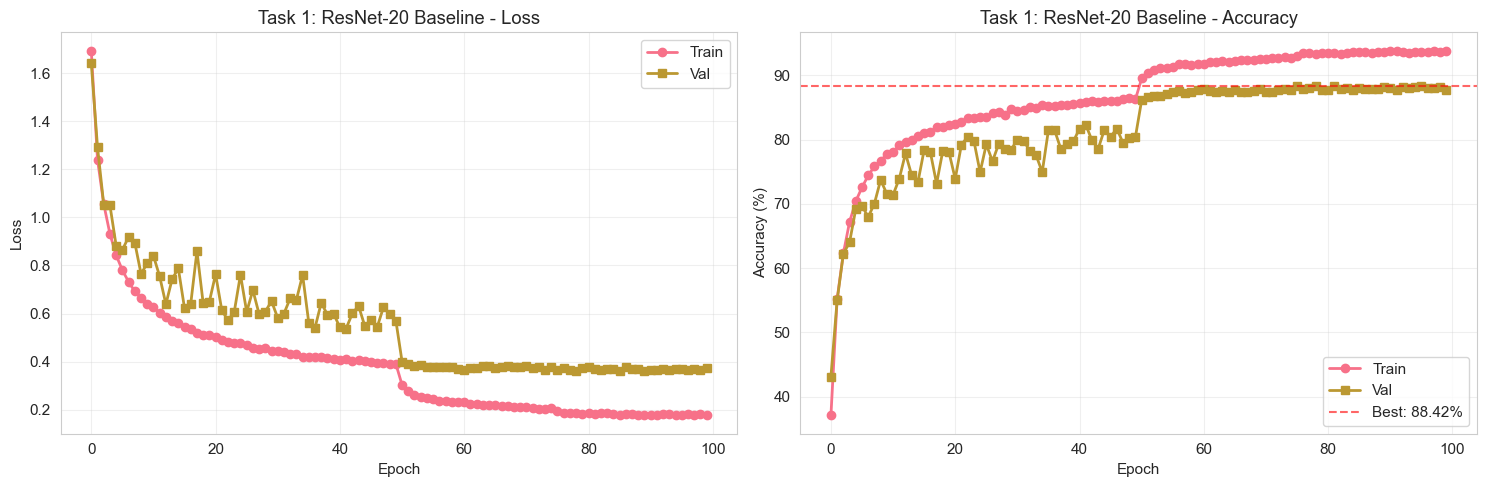


Test Accuracy: 90.21%


In [ ]:
# Task 1: Baseline ResNet-20
print(f"\n{'='*60}")
print("Task 1: Baseline ResNet-20")
print(f"{'='*60}")

model_t1 = ResNetCIFAR(20, use_residual=True, projection='A')
config_t1 = {'epochs': 100, 'lr': 0.1, 'milestones': [50, 75]}
hist_t1 = train_model(model_t1, train_loader, val_loader, config_t1, device)
plot_training_curves(hist_t1, 'Task 1: ResNet-20 Baseline', VISUALIZATION_DIR / 'task1_baseline.png')

test_loss_t1, test_acc_t1 = evaluate(model_t1, test_loader, nn.CrossEntropyLoss(), device)
print(f"\nTest Accuracy: {test_acc_t1*100:.2f}%")

task_histories.append(hist_t1)
task_labels.append('ResNet-20')
task_results.append({'Task': 'Task 1: ResNet-20 Baseline', 'Val_Acc': f"{hist_t1['best_acc']*100:.2f}%",
                     'Test_Acc': f"{test_acc_t1*100:.2f}%", 'Test_Loss': f"{test_loss_t1:.4f}"})

###
### **Task 2: Residual versus Plain network**


Task 2: Residual vs Plain Networks
Epoch   0/80 | Train: 0.3237 | Val: 0.3808 | Best: 0.3808
Epoch  10/80 | Train: 0.7623 | Val: 0.6950 | Best: 0.7300
Epoch  20/80 | Train: 0.8090 | Val: 0.7586 | Best: 0.7674
Epoch  30/80 | Train: 0.8343 | Val: 0.7634 | Best: 0.7839
Epoch  40/80 | Train: 0.8773 | Val: 0.8560 | Best: 0.8560
Epoch  50/80 | Train: 0.9050 | Val: 0.8636 | Best: 0.8638
Epoch  60/80 | Train: 0.9149 | Val: 0.8673 | Best: 0.8695
Epoch  70/80 | Train: 0.9187 | Val: 0.8721 | Best: 0.8734
Epoch  79/80 | Train: 0.9199 | Val: 0.8754 | Best: 0.8754
Epoch   0/80 | Train: 0.3526 | Val: 0.4034 | Best: 0.4034
Epoch  10/80 | Train: 0.7458 | Val: 0.6732 | Best: 0.6859
Epoch  20/80 | Train: 0.7921 | Val: 0.7231 | Best: 0.7450
Epoch  30/80 | Train: 0.8148 | Val: 0.7577 | Best: 0.7689
Epoch  40/80 | Train: 0.8611 | Val: 0.8373 | Best: 0.8373
Epoch  50/80 | Train: 0.8894 | Val: 0.8523 | Best: 0.8531
Epoch  60/80 | Train: 0.9000 | Val: 0.8537 | Best: 0.8550
Epoch  70/80 | Train: 0.9007 | Val: 

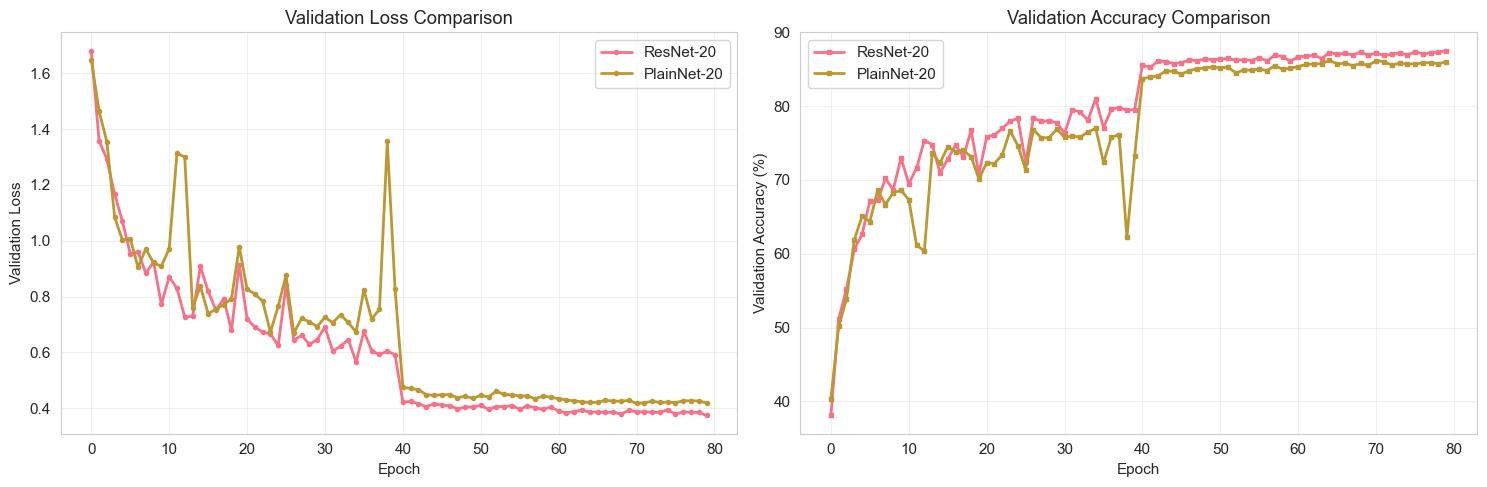

In [ ]:
# Task 2: Residual vs Plain
print(f"\n{'='*60}")
print("Task 2: Residual vs Plain Networks")
print(f"{'='*60}")

model_t2a = ResNetCIFAR(20, use_residual=True, projection='B')
config_t2 = {'epochs': 80, 'lr': 0.1, 'milestones': [40, 60]}
hist_t2a = train_model(model_t2a, train_loader, val_loader, config_t2, device)

model_t2b = ResNetCIFAR(20, use_residual=False)
hist_t2b = train_model(model_t2b, train_loader, val_loader, config_t2, device)

test_loss_t2a, test_acc_t2a = evaluate(model_t2a, test_loader, nn.CrossEntropyLoss(), device)
test_loss_t2b, test_acc_t2b = evaluate(model_t2b, test_loader, nn.CrossEntropyLoss(), device)

print(f"\nResNet-20 Test Acc: {test_acc_t2a*100:.2f}%")
print(f"PlainNet-20 Test Acc: {test_acc_t2b*100:.2f}%")

compare_models([hist_t2a, hist_t2b], ['ResNet-20', 'PlainNet-20'],
                    VISUALIZATION_DIR / 'task2_residual_vs_plain.png')

task_histories.extend([hist_t2a, hist_t2b])
task_labels.extend(['ResNet-20 (Proj B)', 'PlainNet-20'])
task_results.extend([
    {'Task': 'Task 2: ResNet-20 (Proj B)', 'Val_Acc': f"{hist_t2a['best_acc']*100:.2f}%",
     'Test_Acc': f"{test_acc_t2a*100:.2f}%", 'Test_Loss': f"{test_loss_t2a:.4f}"},
    {'Task': 'Task 2: PlainNet-20', 'Val_Acc': f"{hist_t2b['best_acc']*100:.2f}%",
     'Test_Acc': f"{test_acc_t2b*100:.2f}%", 'Test_Loss': f"{test_loss_t2b:.4f}"}
])

###
### **Task 3: Depth Comparison**


Task 3: Network Depth Comparison

Training ResNet-20:
Epoch   0/80 | Train: 0.3661 | Val: 0.4753 | Best: 0.4753
Epoch  10/80 | Train: 0.7802 | Val: 0.7542 | Best: 0.7542
Epoch  20/80 | Train: 0.8234 | Val: 0.7745 | Best: 0.7815
Epoch  30/80 | Train: 0.8427 | Val: 0.7821 | Best: 0.7946
Epoch  40/80 | Train: 0.8828 | Val: 0.8580 | Best: 0.8580
Epoch  50/80 | Train: 0.9108 | Val: 0.8651 | Best: 0.8701
Epoch  60/80 | Train: 0.9217 | Val: 0.8694 | Best: 0.8706
Epoch  70/80 | Train: 0.9239 | Val: 0.8707 | Best: 0.8738
Epoch  79/80 | Train: 0.9245 | Val: 0.8722 | Best: 0.8741
ResNet-20 Test Acc: 89.88%

Training ResNet-32:
Epoch   0/80 | Train: 0.2431 | Val: 0.3338 | Best: 0.3338
Epoch  10/80 | Train: 0.7706 | Val: 0.7395 | Best: 0.7440
Epoch  20/80 | Train: 0.8217 | Val: 0.7454 | Best: 0.7910
Epoch  30/80 | Train: 0.8479 | Val: 0.7963 | Best: 0.8157
Epoch  40/80 | Train: 0.8936 | Val: 0.8596 | Best: 0.8596
Epoch  50/80 | Train: 0.9226 | Val: 0.8733 | Best: 0.8733
Epoch  60/80 | Train: 0.934

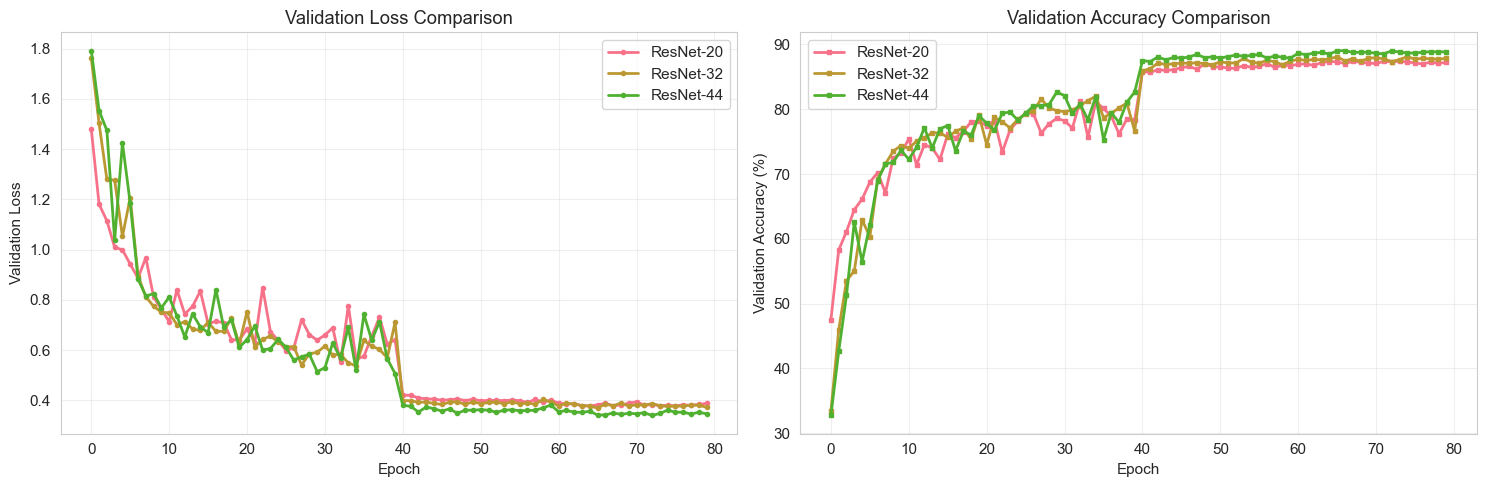

In [ ]:
# Task 3: Depth Comparison
print(f"\n{'='*60}")
print("Task 3: Network Depth Comparison")
print(f"{'='*60}")

depths = [20, 32, 44]
depth_histories = []
config_t3 = {'epochs': 80, 'lr': 0.1, 'milestones': [40, 60]}

for depth in depths:
    print(f"\nTraining ResNet-{depth}:")
    model = ResNetCIFAR(depth, use_residual=True, projection='A')
    hist = train_model(model, train_loader, val_loader, config_t3, device)
    depth_histories.append(hist)

    test_loss, test_acc = evaluate(model, test_loader, nn.CrossEntropyLoss(), device)
    print(f"ResNet-{depth} Test Acc: {test_acc*100:.2f}%")

    task_results.append({'Task': f'Task 3: ResNet-{depth}', 'Val_Acc': f"{hist['best_acc']*100:.2f}%",
                        'Test_Acc': f"{test_acc*100:.2f}%", 'Test_Loss': f"{test_loss:.4f}"})

compare_models(depth_histories, [f'ResNet-{d}' for d in depths],
                   VISUALIZATION_DIR / 'task3_depth_comparison.png')

task_histories.extend(depth_histories)
task_labels.extend([f'ResNet-{d}' for d in depths])

###
### **Task 4: Multi-Layer Skip Connections**


Task 4: Multi-Layer Skip Connections

Training ResNet with 3-layer skip blocks:
Epoch   0/100 | Train: 0.3473 | Val: 0.4581 | Best: 0.4581
Epoch  10/100 | Train: 0.7873 | Val: 0.7408 | Best: 0.7408
Epoch  20/100 | Train: 0.8288 | Val: 0.7890 | Best: 0.7900
Epoch  30/100 | Train: 0.8509 | Val: 0.7956 | Best: 0.8080
Epoch  40/100 | Train: 0.8628 | Val: 0.8083 | Best: 0.8259
Epoch  50/100 | Train: 0.9005 | Val: 0.8710 | Best: 0.8710
Epoch  60/100 | Train: 0.9284 | Val: 0.8777 | Best: 0.8824
Epoch  70/100 | Train: 0.9397 | Val: 0.8839 | Best: 0.8863
Epoch  80/100 | Train: 0.9468 | Val: 0.8858 | Best: 0.8863
Epoch  90/100 | Train: 0.9468 | Val: 0.8832 | Best: 0.8890
Epoch  99/100 | Train: 0.9486 | Val: 0.8861 | Best: 0.8890


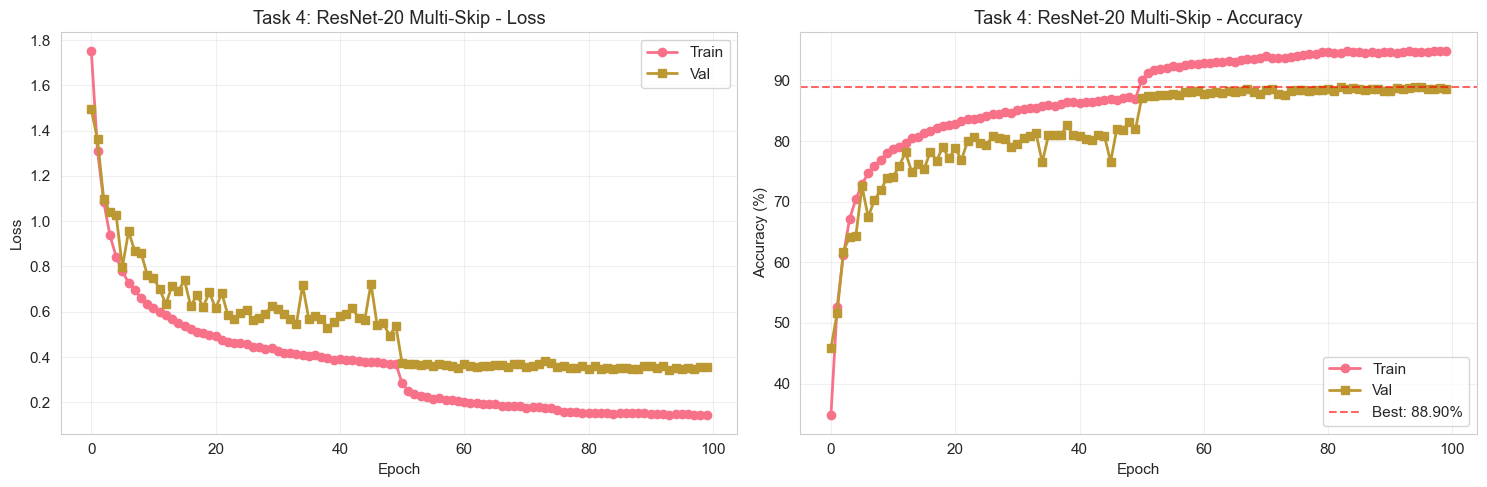


Multi-Skip Test Acc: 90.35%


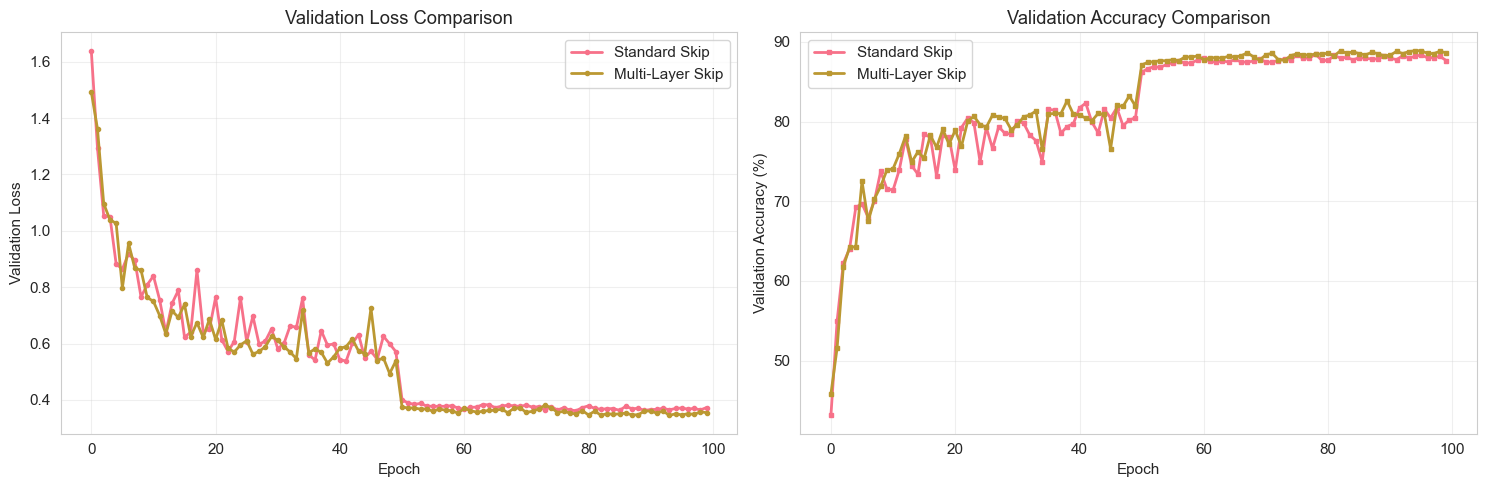

In [ ]:
# Task 4: Multi-Layer Skip Connections
print(f"\n{'='*60}")
print("Task 4: Multi-Layer Skip Connections")
print(f"{'='*60}")

print("\nTraining ResNet with 3-layer skip blocks:")
model_t4 = ResNetCIFAR(20, use_residual=True, projection='A', multi_skip=True)
config_t4 = {'epochs': 100, 'lr': 0.1, 'milestones': [50, 75]}
hist_t4 = train_model(model_t4, train_loader, val_loader, config_t4, device)
plot_training_curves(hist_t4, 'Task 4: ResNet-20 Multi-Skip', VISUALIZATION_DIR / 'task4_multi_skip.png')

test_loss_t4, test_acc_t4 = evaluate(model_t4, test_loader, nn.CrossEntropyLoss(), device)
print(f"\nMulti-Skip Test Acc: {test_acc_t4*100:.2f}%")

task_results.append({'Task': 'Task 4: ResNet-20 Multi-Skip', 'Val_Acc': f"{hist_t4['best_acc']*100:.2f}%",
                    'Test_Acc': f"{test_acc_t4*100:.2f}%", 'Test_Loss': f"{test_loss_t4:.4f}"})

compare_models([hist_t1, hist_t4], ['Standard Skip', 'Multi-Layer Skip'],
                   VISUALIZATION_DIR / 'task4_skip_comparison.png')

task_histories.append(hist_t4)
task_labels.append('Multi-Skip')

###
### **Task 5: Projection Methods Comparison**


Task 5: Projection Method Comparison
Epoch   0/70 | Train: 0.2530 | Val: 0.3031 | Best: 0.3031
Epoch  10/70 | Train: 0.7785 | Val: 0.7130 | Best: 0.7379
Epoch  20/70 | Train: 0.8293 | Val: 0.7862 | Best: 0.7909
Epoch  30/70 | Train: 0.8538 | Val: 0.8113 | Best: 0.8113
Epoch  40/70 | Train: 0.9154 | Val: 0.8711 | Best: 0.8711
Epoch  50/70 | Train: 0.9224 | Val: 0.8736 | Best: 0.8761
Epoch  60/70 | Train: 0.9362 | Val: 0.8797 | Best: 0.8863
Epoch  69/70 | Train: 0.9368 | Val: 0.8772 | Best: 0.8863
Epoch   0/70 | Train: 0.2536 | Val: 0.3023 | Best: 0.3023
Epoch  10/70 | Train: 0.7343 | Val: 0.7168 | Best: 0.7168
Epoch  20/70 | Train: 0.8043 | Val: 0.7289 | Best: 0.7500
Epoch  30/70 | Train: 0.8327 | Val: 0.7650 | Best: 0.8004
Epoch  40/70 | Train: 0.8986 | Val: 0.8515 | Best: 0.8557
Epoch  50/70 | Train: 0.9099 | Val: 0.8552 | Best: 0.8587
Epoch  60/70 | Train: 0.9224 | Val: 0.8665 | Best: 0.8689
Epoch  69/70 | Train: 0.9251 | Val: 0.8596 | Best: 0.8692

Projection A Test Acc: 90.25%
Pro

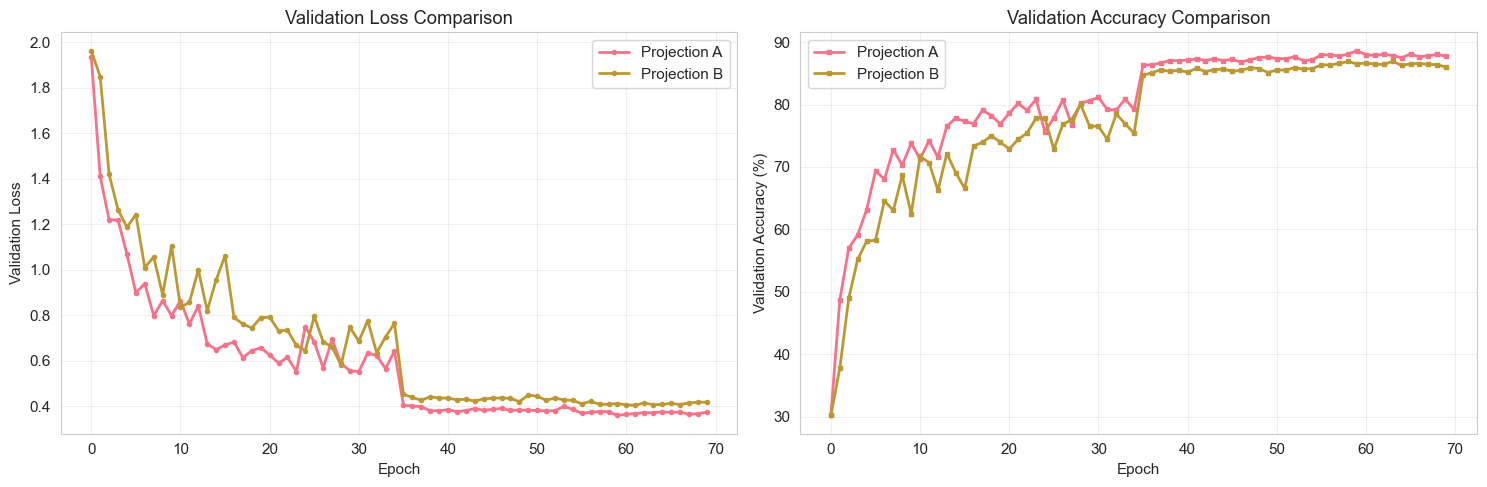

In [ ]:
# Task 5: Projection Methods Comparison
print(f"\n{'='*60}")
print("Task 5: Projection Method Comparison")
print(f"{'='*60}")

model_t5a = ResNetCIFAR(32, use_residual=True, projection='A')
config_t5 = {'epochs': 70, 'lr': 0.1, 'milestones': [35, 55]}
hist_t5a = train_model(model_t5a, train_loader, val_loader, config_t5, device)

model_t5b = ResNetCIFAR(32, use_residual=True, projection='B')
hist_t5b = train_model(model_t5b, train_loader, val_loader, config_t5, device)

test_loss_t5a, test_acc_t5a = evaluate(model_t5a, test_loader, nn.CrossEntropyLoss(), device)
test_loss_t5b, test_acc_t5b = evaluate(model_t5b, test_loader, nn.CrossEntropyLoss(), device)

print(f"\nProjection A Test Acc: {test_acc_t5a*100:.2f}%")
print(f"Projection B Test Acc: {test_acc_t5b*100:.2f}%")

compare_models([hist_t5a, hist_t5b], ['Projection A', 'Projection B'],
                   VISUALIZATION_DIR / 'task5_projection_comparison.png')

task_results.extend([
    {'Task': 'Task 5: ResNet-32 Proj A', 'Val_Acc': f"{hist_t5a['best_acc']*100:.2f}%",
     'Test_Acc': f"{test_acc_t5a*100:.2f}%", 'Test_Loss': f"{test_loss_t5a:.4f}"},
    {'Task': 'Task 5: ResNet-32 Proj B', 'Val_Acc': f"{hist_t5b['best_acc']*100:.2f}%",
     'Test_Acc': f"{test_acc_t5b*100:.2f}%", 'Test_Loss': f"{test_loss_t5b:.4f}"}
])

task_histories.extend([hist_t5a, hist_t5b])
task_labels.extend(['ResNet-32 Proj A', 'ResNet-32 Proj B'])

###
### **Task 6: Degradation Problem Analysis**


Task 6: Degradation Problem Analysis
Training Plain networks of increasing depth:

--- Plain Network Depth 20 ---
PlainNet-20 - Val: 86.29% | Test: 88.68%

--- Plain Network Depth 32 ---
PlainNet-32 - Val: 84.72% | Test: 87.65%

--- Plain Network Depth 44 ---
PlainNet-44 - Val: 81.38% | Test: 84.48%

--- Plain Network Depth 56 ---
PlainNet-56 - Val: 79.61% | Test: 82.67%

Training ResNets of increasing depth:

--- ResNet Depth 20 ---
ResNet-20 - Val: 86.51% | Test: 89.06%

--- ResNet Depth 32 ---
ResNet-32 - Val: 87.17% | Test: 88.74%

--- ResNet Depth 44 ---
ResNet-44 - Val: 86.86% | Test: 89.00%

--- ResNet Depth 56 ---
ResNet-56 - Val: 88.84% | Test: 90.65%

Degradation Analysis Table
 Depth   Type  Train_Acc  Val_Acc  Test_Acc  Train_Loss  Convergence_Epoch
    20  Plain    90.5350    86.29     88.68    0.265190                 69
    32  Plain    88.2875    84.72     87.65    0.332165                 75
    44  Plain    85.6575    81.38     84.48    0.413648                 77
  

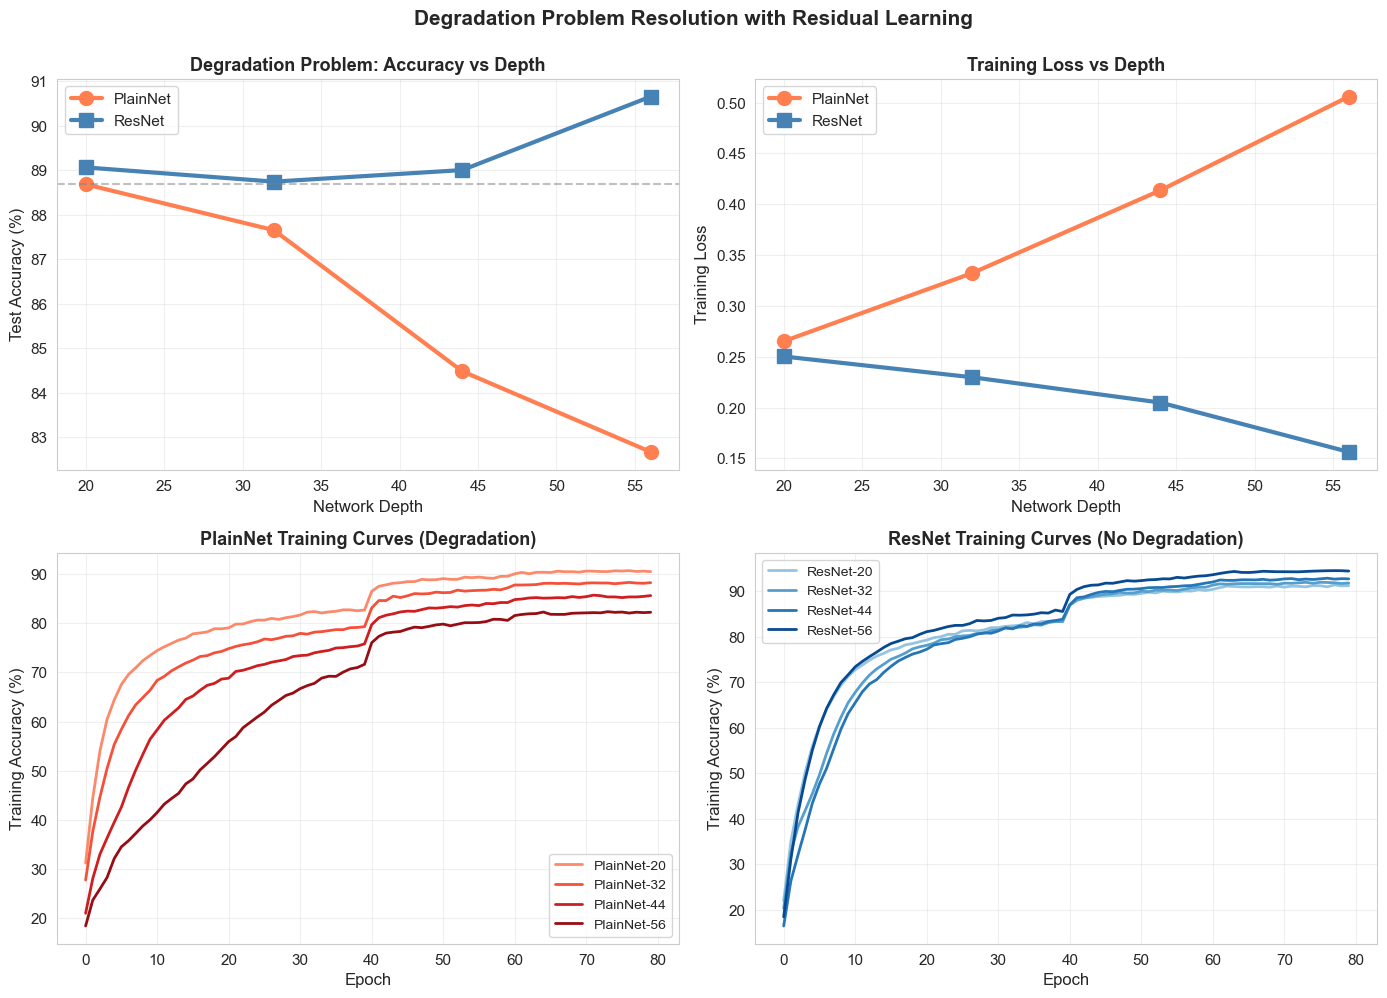


Degradation Metrics

PlainNet Performance:
  20 layers: 88.68%
  56 layers: 82.67%
  Degradation: 6.01% (WORSE with more layers)

ResNet Performance:
  20 layers: 89.06%
  56 layers: 90.65%
  Improvement: +1.59% (BETTER with more layers)

Degradation Resolution:
  PlainNet shows degradation: True
  ResNet resolves degradation: True
  Performance gap at 56 layers: 7.98%


In [ ]:
# Task 6: Degradation Problem Analysis
print(f"\n{'='*60}")
print("Task 6: Degradation Problem Analysis")
print(f"{'='*60}")

print("Training Plain networks of increasing depth:")

degradation_results = []
plain_histories = []
resnet_histories = []
test_depths = [20, 32, 44, 56]
config_deg = {'epochs': 80, 'lr': 0.1, 'milestones': [40, 60]}

for depth in test_depths:
    print(f"\n--- Plain Network Depth {depth} ---")
    model_plain = ResNetCIFAR(depth, use_residual=False)
    hist_plain = train_model(model_plain, train_loader, val_loader, config_deg, device, verbose=False)
    plain_histories.append(hist_plain)

    test_loss_p, test_acc_p = evaluate(model_plain, test_loader, nn.CrossEntropyLoss(), device)
    print(f"PlainNet-{depth} - Val: {hist_plain['best_acc']*100:.2f}% | Test: {test_acc_p*100:.2f}%")

    degradation_results.append({
        'Depth': depth,
        'Type': 'Plain',
        'Train_Acc': hist_plain['train_acc'][-1]*100,
        'Val_Acc': hist_plain['best_acc']*100,
        'Test_Acc': test_acc_p*100,
        'Train_Loss': hist_plain['train_loss'][-1],
        'Convergence_Epoch': hist_plain['best_epoch']
    })

print("\nTraining ResNets of increasing depth:")

for depth in test_depths:
    print(f"\n--- ResNet Depth {depth} ---")
    model_res = ResNetCIFAR(depth, use_residual=True, projection='B')
    hist_res = train_model(model_res, train_loader, val_loader, config_deg, device, verbose=False)
    resnet_histories.append(hist_res)

    test_loss_r, test_acc_r = evaluate(model_res, test_loader, nn.CrossEntropyLoss(), device)
    print(f"ResNet-{depth} - Val: {hist_res['best_acc']*100:.2f}% | Test: {test_acc_r*100:.2f}%")

    degradation_results.append({
        'Depth': depth,
        'Type': 'ResNet',
        'Train_Acc': hist_res['train_acc'][-1]*100,
        'Val_Acc': hist_res['best_acc']*100,
        'Test_Acc': test_acc_r*100,
        'Train_Loss': hist_res['train_loss'][-1],
        'Convergence_Epoch': hist_res['best_epoch']
    })

deg_df = pd.DataFrame(degradation_results)
print(f"\n{'='*60}")
print("Degradation Analysis Table")
print(f"{'='*60}")
print(deg_df.to_string(index=False))
deg_df.to_csv(RESULTS_DIR / 'degradation_analysis.csv', index=False)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax1 = axes[0, 0]
plain_test_accs = deg_df[deg_df['Type']=='Plain']['Test_Acc'].values
resnet_test_accs = deg_df[deg_df['Type']=='ResNet']['Test_Acc'].values
ax1.plot(test_depths, plain_test_accs, 'o-', linewidth=3, markersize=10,
         label='PlainNet', color='coral')
ax1.plot(test_depths, resnet_test_accs, 's-', linewidth=3, markersize=10,
         label='ResNet', color='steelblue')
ax1.set_xlabel('Network Depth', fontsize=12)
ax1.set_ylabel('Test Accuracy (%)', fontsize=12)
ax1.set_title('Degradation Problem: Accuracy vs Depth', fontsize=13, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(alpha=0.3)
ax1.axhline(y=plain_test_accs[0], linestyle='--', alpha=0.5, color='gray')

ax2 = axes[0, 1]
plain_train_loss = deg_df[deg_df['Type']=='Plain']['Train_Loss'].values
resnet_train_loss = deg_df[deg_df['Type']=='ResNet']['Train_Loss'].values
ax2.plot(test_depths, plain_train_loss, 'o-', linewidth=3, markersize=10,
         label='PlainNet', color='coral')
ax2.plot(test_depths, resnet_train_loss, 's-', linewidth=3, markersize=10,
         label='ResNet', color='steelblue')
ax2.set_xlabel('Network Depth', fontsize=12)
ax2.set_ylabel('Training Loss', fontsize=12)
ax2.set_title('Training Loss vs Depth', fontsize=13, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(alpha=0.3)

ax3 = axes[1, 0]
colors = plt.cm.Reds(np.linspace(0.4, 0.9, len(test_depths)))
for i, (hist, depth) in enumerate(zip(plain_histories, test_depths)):
    ax3.plot(hist['epoch'], [a*100 for a in hist['train_acc']],
             linewidth=2, color=colors[i], label=f'PlainNet-{depth}')
ax3.set_xlabel('Epoch', fontsize=12)
ax3.set_ylabel('Training Accuracy (%)', fontsize=12)
ax3.set_title('PlainNet Training Curves (Degradation)', fontsize=13, fontweight='bold')
ax3.legend(fontsize=10)
ax3.grid(alpha=0.3)

ax4 = axes[1, 1]
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(test_depths)))
for i, (hist, depth) in enumerate(zip(resnet_histories, test_depths)):
    ax4.plot(hist['epoch'], [a*100 for a in hist['train_acc']],
             linewidth=2, color=colors[i], label=f'ResNet-{depth}')
ax4.set_xlabel('Epoch', fontsize=12)
ax4.set_ylabel('Training Accuracy (%)', fontsize=12)
ax4.set_title('ResNet Training Curves (No Degradation)', fontsize=13, fontweight='bold')
ax4.legend(fontsize=10)
ax4.grid(alpha=0.3)

plt.suptitle('Degradation Problem Resolution with Residual Learning',
             fontsize=15, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig(VISUALIZATION_DIR / 'task6_degradation_problem.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

print(f"\n{'='*60}")
print("Degradation Metrics")
print(f"{'='*60}")

plain_20 = deg_df[(deg_df['Type']=='Plain') & (deg_df['Depth']==20)]['Test_Acc'].values[0]
plain_56 = deg_df[(deg_df['Type']=='Plain') & (deg_df['Depth']==56)]['Test_Acc'].values[0]
resnet_20 = deg_df[(deg_df['Type']=='ResNet') & (deg_df['Depth']==20)]['Test_Acc'].values[0]
resnet_56 = deg_df[(deg_df['Type']=='ResNet') & (deg_df['Depth']==56)]['Test_Acc'].values[0]

plain_degradation = plain_20 - plain_56
resnet_improvement = resnet_56 - resnet_20

print(f"\nPlainNet Performance:")
print(f"  20 layers: {plain_20:.2f}%")
print(f"  56 layers: {plain_56:.2f}%")
print(f"  Degradation: {plain_degradation:.2f}% (WORSE with more layers)")

print(f"\nResNet Performance:")
print(f"  20 layers: {resnet_20:.2f}%")
print(f"  56 layers: {resnet_56:.2f}%")
print(f"  Improvement: {resnet_improvement:+.2f}% (BETTER with more layers)")

print(f"\nDegradation Resolution:")
print(f"  PlainNet shows degradation: {plain_degradation > 0}")
print(f"  ResNet resolves degradation: {resnet_improvement > 0}")
print(f"  Performance gap at 56 layers: {resnet_56 - plain_56:.2f}%")

for res in degradation_results:
    task_results.append({
        'Task': f"Task 6: {res['Type']}-{res['Depth']}",
        'Val_Acc': f"{res['Val_Acc']:.2f}%",
        'Test_Acc': f"{res['Test_Acc']:.2f}%",
        'Test_Loss': f"{res['Train_Loss']:.4f}"
    })

###
### **Experimentation Tasks Summary**

Experiment Summary
                        Task Val_Acc Test_Acc  Test_Loss
  Task 1: ResNet-20 Baseline  88.42%   90.21%     0.3161
  Task 2: ResNet-20 (Proj B)  87.54%   89.15%     0.3345
         Task 2: PlainNet-20  86.20%   88.70%     0.3473
           Task 3: ResNet-20  87.41%   89.88%     0.3293
           Task 3: ResNet-32  88.14%   90.42%     0.3223
           Task 3: ResNet-44  89.06%   90.58%     0.3077
Task 4: ResNet-20 Multi-Skip  88.90%   90.35%     0.3144
    Task 5: ResNet-32 Proj A  88.63%   90.25%     0.3136
    Task 5: ResNet-32 Proj B  86.92%   89.27%     0.3446
            Task 6: Plain-20  86.29%   88.68%     0.2652
            Task 6: Plain-32  84.72%   87.65%     0.3322
            Task 6: Plain-44  81.38%   84.48%     0.4136
            Task 6: Plain-56  79.61%   82.67%     0.5058
           Task 6: ResNet-20  86.51%   89.06%     0.2502
           Task 6: ResNet-32  87.17%   88.74%     0.2298
           Task 6: ResNet-44  86.86%   89.00%     0.2049
           T

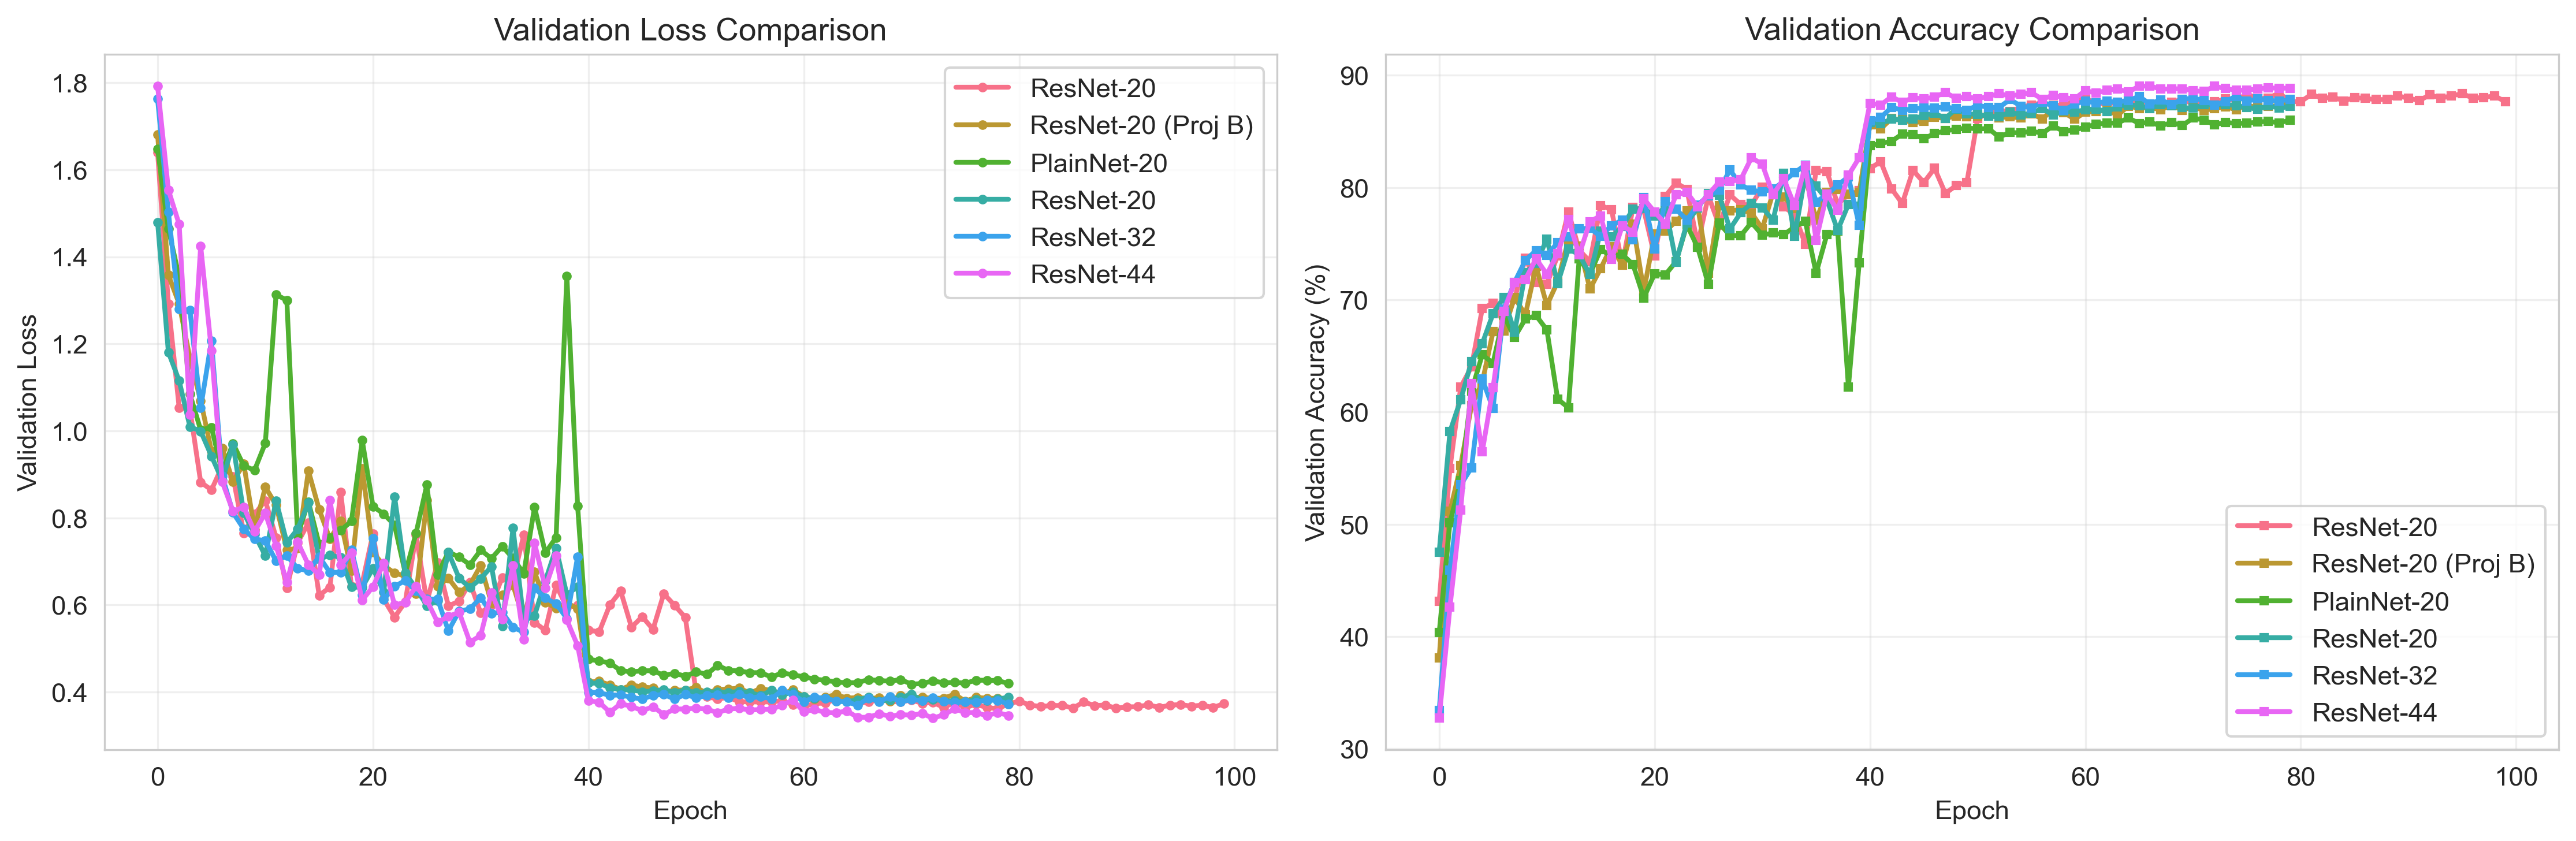

In [ ]:
# Task Summary
task_summary_df = create_summary_table(task_results, RESULTS_DIR / 'task_summary.csv')
compare_models(task_histories[:6], task_labels[:6], VISUALIZATION_DIR / 'task_comparison.png')

###
### **Experiment 1: Hyperparameter Grid Search**


Experiment 1: Hyperparameter Grid Search

Grid Search (27 combinations)

[1/27] {'lr': 0.05, 'weight_decay': 0.0001, 'momentum': 0.85, 'batch_size': 128, 'epochs': 40}
Best Val Acc: 0.5520

[2/27] {'lr': 0.05, 'weight_decay': 0.0001, 'momentum': 0.9, 'batch_size': 128, 'epochs': 40}
Best Val Acc: 0.6350

[3/27] {'lr': 0.05, 'weight_decay': 0.0001, 'momentum': 0.95, 'batch_size': 128, 'epochs': 40}
Best Val Acc: 0.6350

[4/27] {'lr': 0.05, 'weight_decay': 0.0005, 'momentum': 0.85, 'batch_size': 128, 'epochs': 40}
Best Val Acc: 0.6220

[5/27] {'lr': 0.05, 'weight_decay': 0.0005, 'momentum': 0.9, 'batch_size': 128, 'epochs': 40}
Best Val Acc: 0.6330

[6/27] {'lr': 0.05, 'weight_decay': 0.0005, 'momentum': 0.95, 'batch_size': 128, 'epochs': 40}
Best Val Acc: 0.6250

[7/27] {'lr': 0.05, 'weight_decay': 0.001, 'momentum': 0.85, 'batch_size': 128, 'epochs': 40}
Best Val Acc: 0.5710

[8/27] {'lr': 0.05, 'weight_decay': 0.001, 'momentum': 0.9, 'batch_size': 128, 'epochs': 40}
Best Val Acc: 0.5

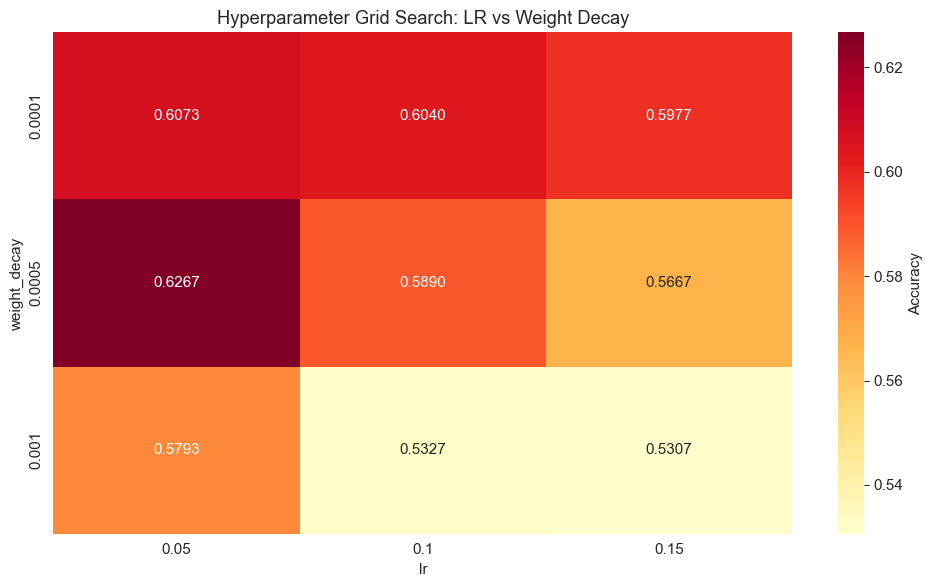

In [ ]:
exp_results = []

# Experiment 1: Hyperparameter Grid Search
print(f"\n{'='*60}")
print("Experiment 1: Hyperparameter Grid Search")
print(f"{'='*60}")

small_train, _ = random_split(train_subset, [5000, len(train_subset) - 5000])
small_val, _ = random_split(val_subset, [1000, len(val_subset) - 1000])

param_grid = {
    'lr': [0.05, 0.1, 0.15],
    'weight_decay': [1e-4, 5e-4, 1e-3],
    'momentum': [0.85, 0.9, 0.95],
    'batch_size': [128],
    'epochs': [40]
}

grid_results = grid_search(lambda: ResNetCIFAR(20, use_residual=True, projection='A'),
                          small_train, small_val, param_grid, device)

if len(grid_results) > 1:
    pivot = grid_results.pivot_table(values='best_acc', index='weight_decay',
                                     columns='lr', aggfunc='mean')
    plt.figure(figsize=(10, 6))
    sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlOrRd', cbar_kws={'label': 'Accuracy'})
    plt.title('Hyperparameter Grid Search: LR vs Weight Decay')
    plt.tight_layout()
    plt.savefig(VISUALIZATION_DIR / 'experiment1_grid_search_heatmap.png', dpi=300)
    plt.show()
    plt.close()

best_params = grid_results.iloc[0]
exp_results.append({
    'Experiment': 'Experiment 1: Grid Search',
    'Best_LR': best_params['lr'],
    'Best_WD': best_params['weight_decay'],
    'Best_Momentum': best_params['momentum'],
    'Best_Val_Acc': f"{best_params['best_acc']*100:.2f}%"
})

###
### **Experiment 2: Learning Rate Sensitivity**


Experiment 2: Learning Rate Sensitivity

Training with LR=0.01...
Epoch   0/60 | Train: 0.3098 | Val: 0.4000 | Best: 0.4000
Epoch  10/60 | Train: 0.7096 | Val: 0.7049 | Best: 0.7049
Epoch  20/60 | Train: 0.7844 | Val: 0.7557 | Best: 0.7557
Epoch  30/60 | Train: 0.8344 | Val: 0.8193 | Best: 0.8193
Epoch  40/60 | Train: 0.8471 | Val: 0.8199 | Best: 0.8208
Epoch  50/60 | Train: 0.8517 | Val: 0.8231 | Best: 0.8284
Epoch  59/60 | Train: 0.8545 | Val: 0.8203 | Best: 0.8301
LR=0.01 Test Acc: 85.69%

Training with LR=0.05...
Epoch   0/60 | Train: 0.3760 | Val: 0.4820 | Best: 0.4820
Epoch  10/60 | Train: 0.7748 | Val: 0.7261 | Best: 0.7463
Epoch  20/60 | Train: 0.8230 | Val: 0.7972 | Best: 0.7972
Epoch  30/60 | Train: 0.8701 | Val: 0.8437 | Best: 0.8437
Epoch  40/60 | Train: 0.8905 | Val: 0.8528 | Best: 0.8528
Epoch  50/60 | Train: 0.8986 | Val: 0.8556 | Best: 0.8586
Epoch  59/60 | Train: 0.9011 | Val: 0.8617 | Best: 0.8632
LR=0.05 Test Acc: 88.23%

Training with LR=0.1...
Epoch   0/60 | Train

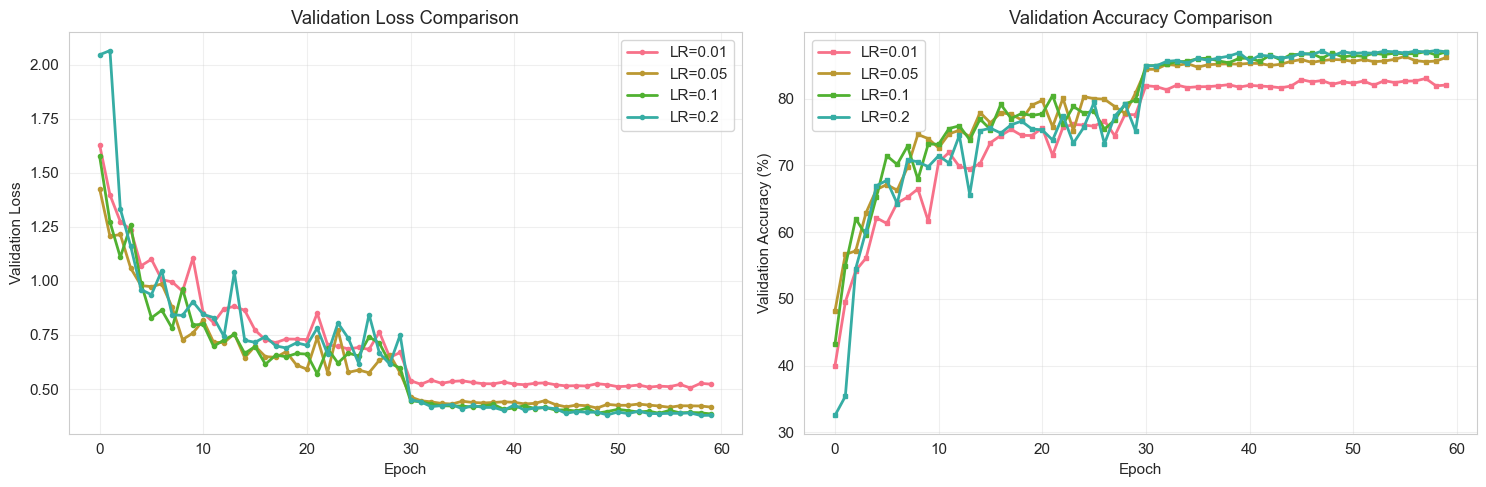

In [ ]:
# Experiment 2: Learning Rate Sensitivity
print(f"\n{'='*60}")
print("Experiment 2: Learning Rate Sensitivity")
print(f"{'='*60}")

lrs = [0.01, 0.05, 0.1, 0.2]
lr_histories = []

for lr in lrs:
    print(f"\nTraining with LR={lr}...")
    model = ResNetCIFAR(20, use_residual=True, projection='A')
    config = {'epochs': 60, 'lr': lr, 'milestones': [30, 45]}
    hist = train_model(model, train_loader, val_loader, config, device)
    lr_histories.append(hist)

    test_loss, test_acc = evaluate(model, test_loader, nn.CrossEntropyLoss(), device)
    print(f"LR={lr} Test Acc: {test_acc*100:.2f}%")

    exp_results.append({
        'Experiment': f'Experiment 2: LR={lr}',
        'Val_Acc': f"{hist['best_acc']*100:.2f}%",
        'Test_Acc': f"{test_acc*100:.2f}%",
        'Test_Loss': f"{test_loss:.4f}"
    })

compare_models(lr_histories, [f'LR={lr}' for lr in lrs],
                   VISUALIZATION_DIR / 'experiment2_lr_sensitivity.png')

###
### **Experiment 3: K-Fold Cross-Validation**


Experiment 3: 5-Fold Cross-Validation

K-Fold Cross Validation (k=5)

Fold 1/5
Fold 1 Best Accuracy: 0.8628

Fold 2/5
Fold 2 Best Accuracy: 0.8604

Fold 3/5
Fold 3 Best Accuracy: 0.8683

Fold 4/5
Fold 4 Best Accuracy: 0.8670

Fold 5/5
Fold 5 Best Accuracy: 0.8701

CV Results: 0.8657 ± 0.0036
Range: [0.8604, 0.8701]



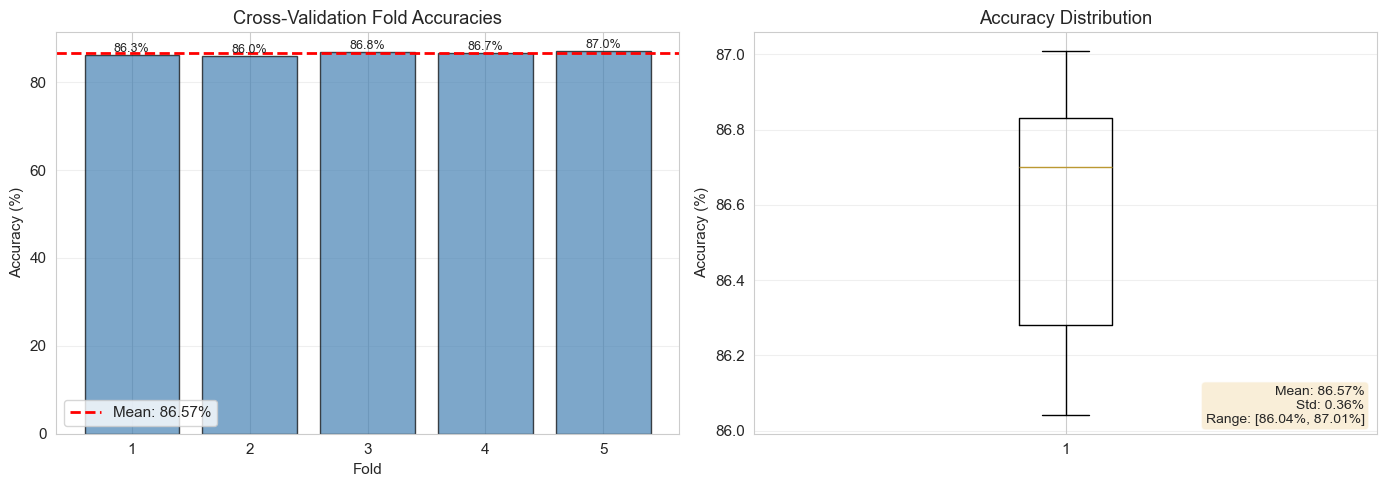

In [ ]:
# Experiment 3: K-Fold Cross-Validation
print(f"\n{'='*60}")
print("Experiment 3: 5-Fold Cross-Validation")
print(f"{'='*60}")

cv_config = {'epochs': 50, 'lr': 0.1, 'batch_size': 128, 'milestones': [25, 40]}
cv_results = k_fold_cv(lambda: ResNetCIFAR(20, use_residual=True, projection='A'),
                       train_data, k=5, config=cv_config, device=device)
plot_cv_results(cv_results, VISUALIZATION_DIR / 'experiment3_cross_validation.png')

with open(RESULTS_DIR / 'cv_results.pkl', 'wb') as f:
    pickle.dump(cv_results, f)

exp_results.append({
    'Experiment': 'Experiment 3: 5-Fold CV',
    'Mean_Acc': f"{cv_results['mean']*100:.2f}%",
    'Std': f"{cv_results['std']*100:.2f}%",
    'CI_Range': f"[{cv_results['min']*100:.2f}%, {cv_results['max']*100:.2f}%]"
})

###
### **Experiment 4: Bootstrap Evaluation**


Experiment 4: Bootstrap Evaluation on Test Set

Bootstrap Evaluation (20 samples)
Sample 1/20: Acc = 0.9024
Sample 6/20: Acc = 0.8971
Sample 11/20: Acc = 0.9001
Sample 16/20: Acc = 0.9052

Bootstrap Mean: 0.9030 ± 0.0029
95% CI: [0.8975, 0.9080]



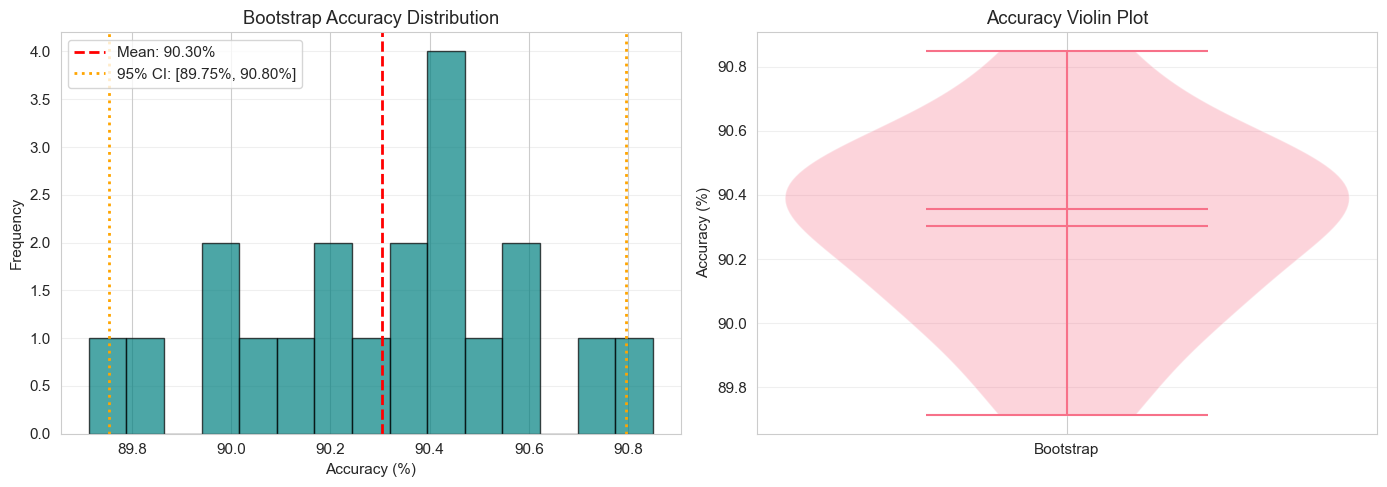

In [ ]:
# Experiment 4: Bootstrap Evaluation
print(f"\n{'='*60}")
print("Experiment 4: Bootstrap Evaluation on Test Set")
print(f"{'='*60}")

boot_results = bootstrap_eval(model_t1, test_data, n_samples=20, sample_frac=0.8, device=device)
plot_bootstrap_results(boot_results, VISUALIZATION_DIR / 'experiment4_bootstrap.png')

with open(RESULTS_DIR / 'bootstrap_results.pkl', 'wb') as f:
    pickle.dump(boot_results, f)

ci_low, ci_high = boot_results['ci_95']
exp_results.append({
    'Experiment': 'Experiment 4: Bootstrap',
    'Mean_Acc': f"{boot_results['mean']*100:.2f}%",
    'Std': f"{boot_results['std']*100:.2f}%",
    'CI_95': f"[{ci_low*100:.2f}%, {ci_high*100:.2f}%]"
})

###
### **Experiment 5: Optimized Configuration**


Experiment 5: Optimized Configuration (Best Setup)

Training optimized model:
Epoch   0/120 | Train: 0.1593 | Val: 0.2280 | Best: 0.2280
Epoch  10/120 | Train: 0.7149 | Val: 0.6242 | Best: 0.6656
Epoch  20/120 | Train: 0.7608 | Val: 0.6352 | Best: 0.7051
Epoch  30/120 | Train: 0.7816 | Val: 0.7175 | Best: 0.7364
Epoch  40/120 | Train: 0.7945 | Val: 0.5946 | Best: 0.7530
Epoch  50/120 | Train: 0.8011 | Val: 0.6838 | Best: 0.7566
Epoch  60/120 | Train: 0.8563 | Val: 0.8454 | Best: 0.8454
Epoch  70/120 | Train: 0.9007 | Val: 0.8643 | Best: 0.8657
Epoch  80/120 | Train: 0.9066 | Val: 0.8718 | Best: 0.8718
Epoch  90/120 | Train: 0.9262 | Val: 0.8863 | Best: 0.8863
Epoch 100/120 | Train: 0.9424 | Val: 0.8868 | Best: 0.8868
Epoch 110/120 | Train: 0.9475 | Val: 0.8890 | Best: 0.8903
Epoch 119/120 | Train: 0.9490 | Val: 0.8855 | Best: 0.8916


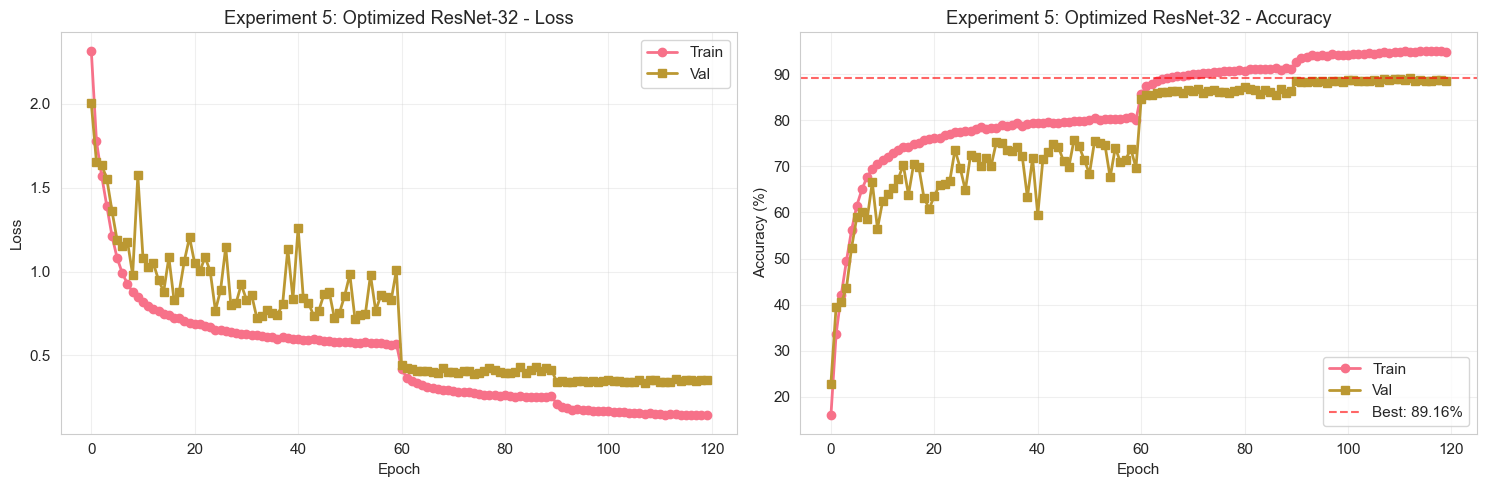


Optimized Model Test Acc: 91.16%


In [ ]:
# Experiment 5: Optimized Configuration
print(f"\n{'='*60}")
print("Experiment 5: Optimized Configuration (Best Setup)")
print(f"{'='*60}")

model_e5 = ResNetCIFAR(32, use_residual=True, projection='B', multi_skip=False)
config_e5 = {
    'epochs': 120,
    'lr': 0.1,
    'momentum': 0.9,
    'weight_decay': 5e-4,
    'nesterov': True,
    'milestones': [60, 90],
    'gamma': 0.1
}

print("\nTraining optimized model:")
hist_e5 = train_model(model_e5, train_loader, val_loader, config_e5, device)
plot_training_curves(hist_e5, 'Experiment 5: Optimized ResNet-32', VISUALIZATION_DIR / 'experiment5_optimized.png')

test_loss_e5, test_acc_e5 = evaluate(model_e5, test_loader, nn.CrossEntropyLoss(), device)
print(f"\nOptimized Model Test Acc: {test_acc_e5*100:.2f}%")

exp_results.append({
    'Experiment': 'Experiment 5: Optimized ResNet-32',
    'Val_Acc': f"{hist_e5['best_acc']*100:.2f}%",
    'Test_Acc': f"{test_acc_e5*100:.2f}%",
    'Test_Loss': f"{test_loss_e5:.4f}"
})

###
### **Experiment Summary**

In [ ]:
# Experiment Summary
exp_summary_df = create_summary_table(exp_results, RESULTS_DIR / 'experiment_summary.csv')

Experiment Summary
                       Experiment Best_LR Best_WD Best_Momentum Best_Val_Acc Val_Acc Test_Acc Test_Loss Mean_Acc   Std         CI_Range            CI_95
        Experiment 1: Grid Search    0.05  0.0001           0.9       63.50%     NaN      NaN       NaN      NaN   NaN              NaN              NaN
            Experiment 2: LR=0.01     NaN     NaN           NaN          NaN  83.01%   85.69%    0.4331      NaN   NaN              NaN              NaN
            Experiment 2: LR=0.05     NaN     NaN           NaN          NaN  86.32%   88.23%    0.3587      NaN   NaN              NaN              NaN
             Experiment 2: LR=0.1     NaN     NaN           NaN          NaN  87.03%   89.21%    0.3364      NaN   NaN              NaN              NaN
             Experiment 2: LR=0.2     NaN     NaN           NaN          NaN  87.19%   89.23%    0.3335      NaN   NaN              NaN              NaN
          Experiment 3: 5-Fold CV     NaN     NaN           NaN

In [ ]:
# Final Comprehensive Summary
print(f"\n{'='*60}")
print("Final Comprehensive Summary")
print(f"{'='*60}\n")

print("--- Cross-Validation Results ---")
print(f"Mean Accuracy: {cv_results['mean']*100:.2f}% ± {cv_results['std']*100:.2f}%")
print(f"Min: {cv_results['min']*100:.2f}% | Max: {cv_results['max']*100:.2f}%")

print("\n--- Bootstrap Results (Test Set) ---")
print(f"Mean Accuracy: {boot_results['mean']*100:.2f}% ± {boot_results['std']*100:.2f}%")
print(f"95% Confidence Interval: [{ci_low*100:.2f}%, {ci_high*100:.2f}%]")

print("\n--- Best Hyperparameters (Grid Search) ---")
print(f"Learning Rate: {best_params['lr']}")
print(f"Weight Decay: {best_params['weight_decay']}")
print(f"Momentum: {best_params['momentum']}")
print(f"Best Validation Accuracy: {best_params['best_acc']*100:.2f}%")


Final Comprehensive Summary

--- Cross-Validation Results ---
Mean Accuracy: 86.57% ± 0.36%
Min: 86.04% | Max: 87.01%

--- Bootstrap Results (Test Set) ---
Mean Accuracy: 90.30% ± 0.29%
95% Confidence Interval: [89.75%, 90.80%]

--- Best Hyperparameters (Grid Search) ---
Learning Rate: 0.05
Weight Decay: 0.0001
Momentum: 0.9
Best Validation Accuracy: 63.50%


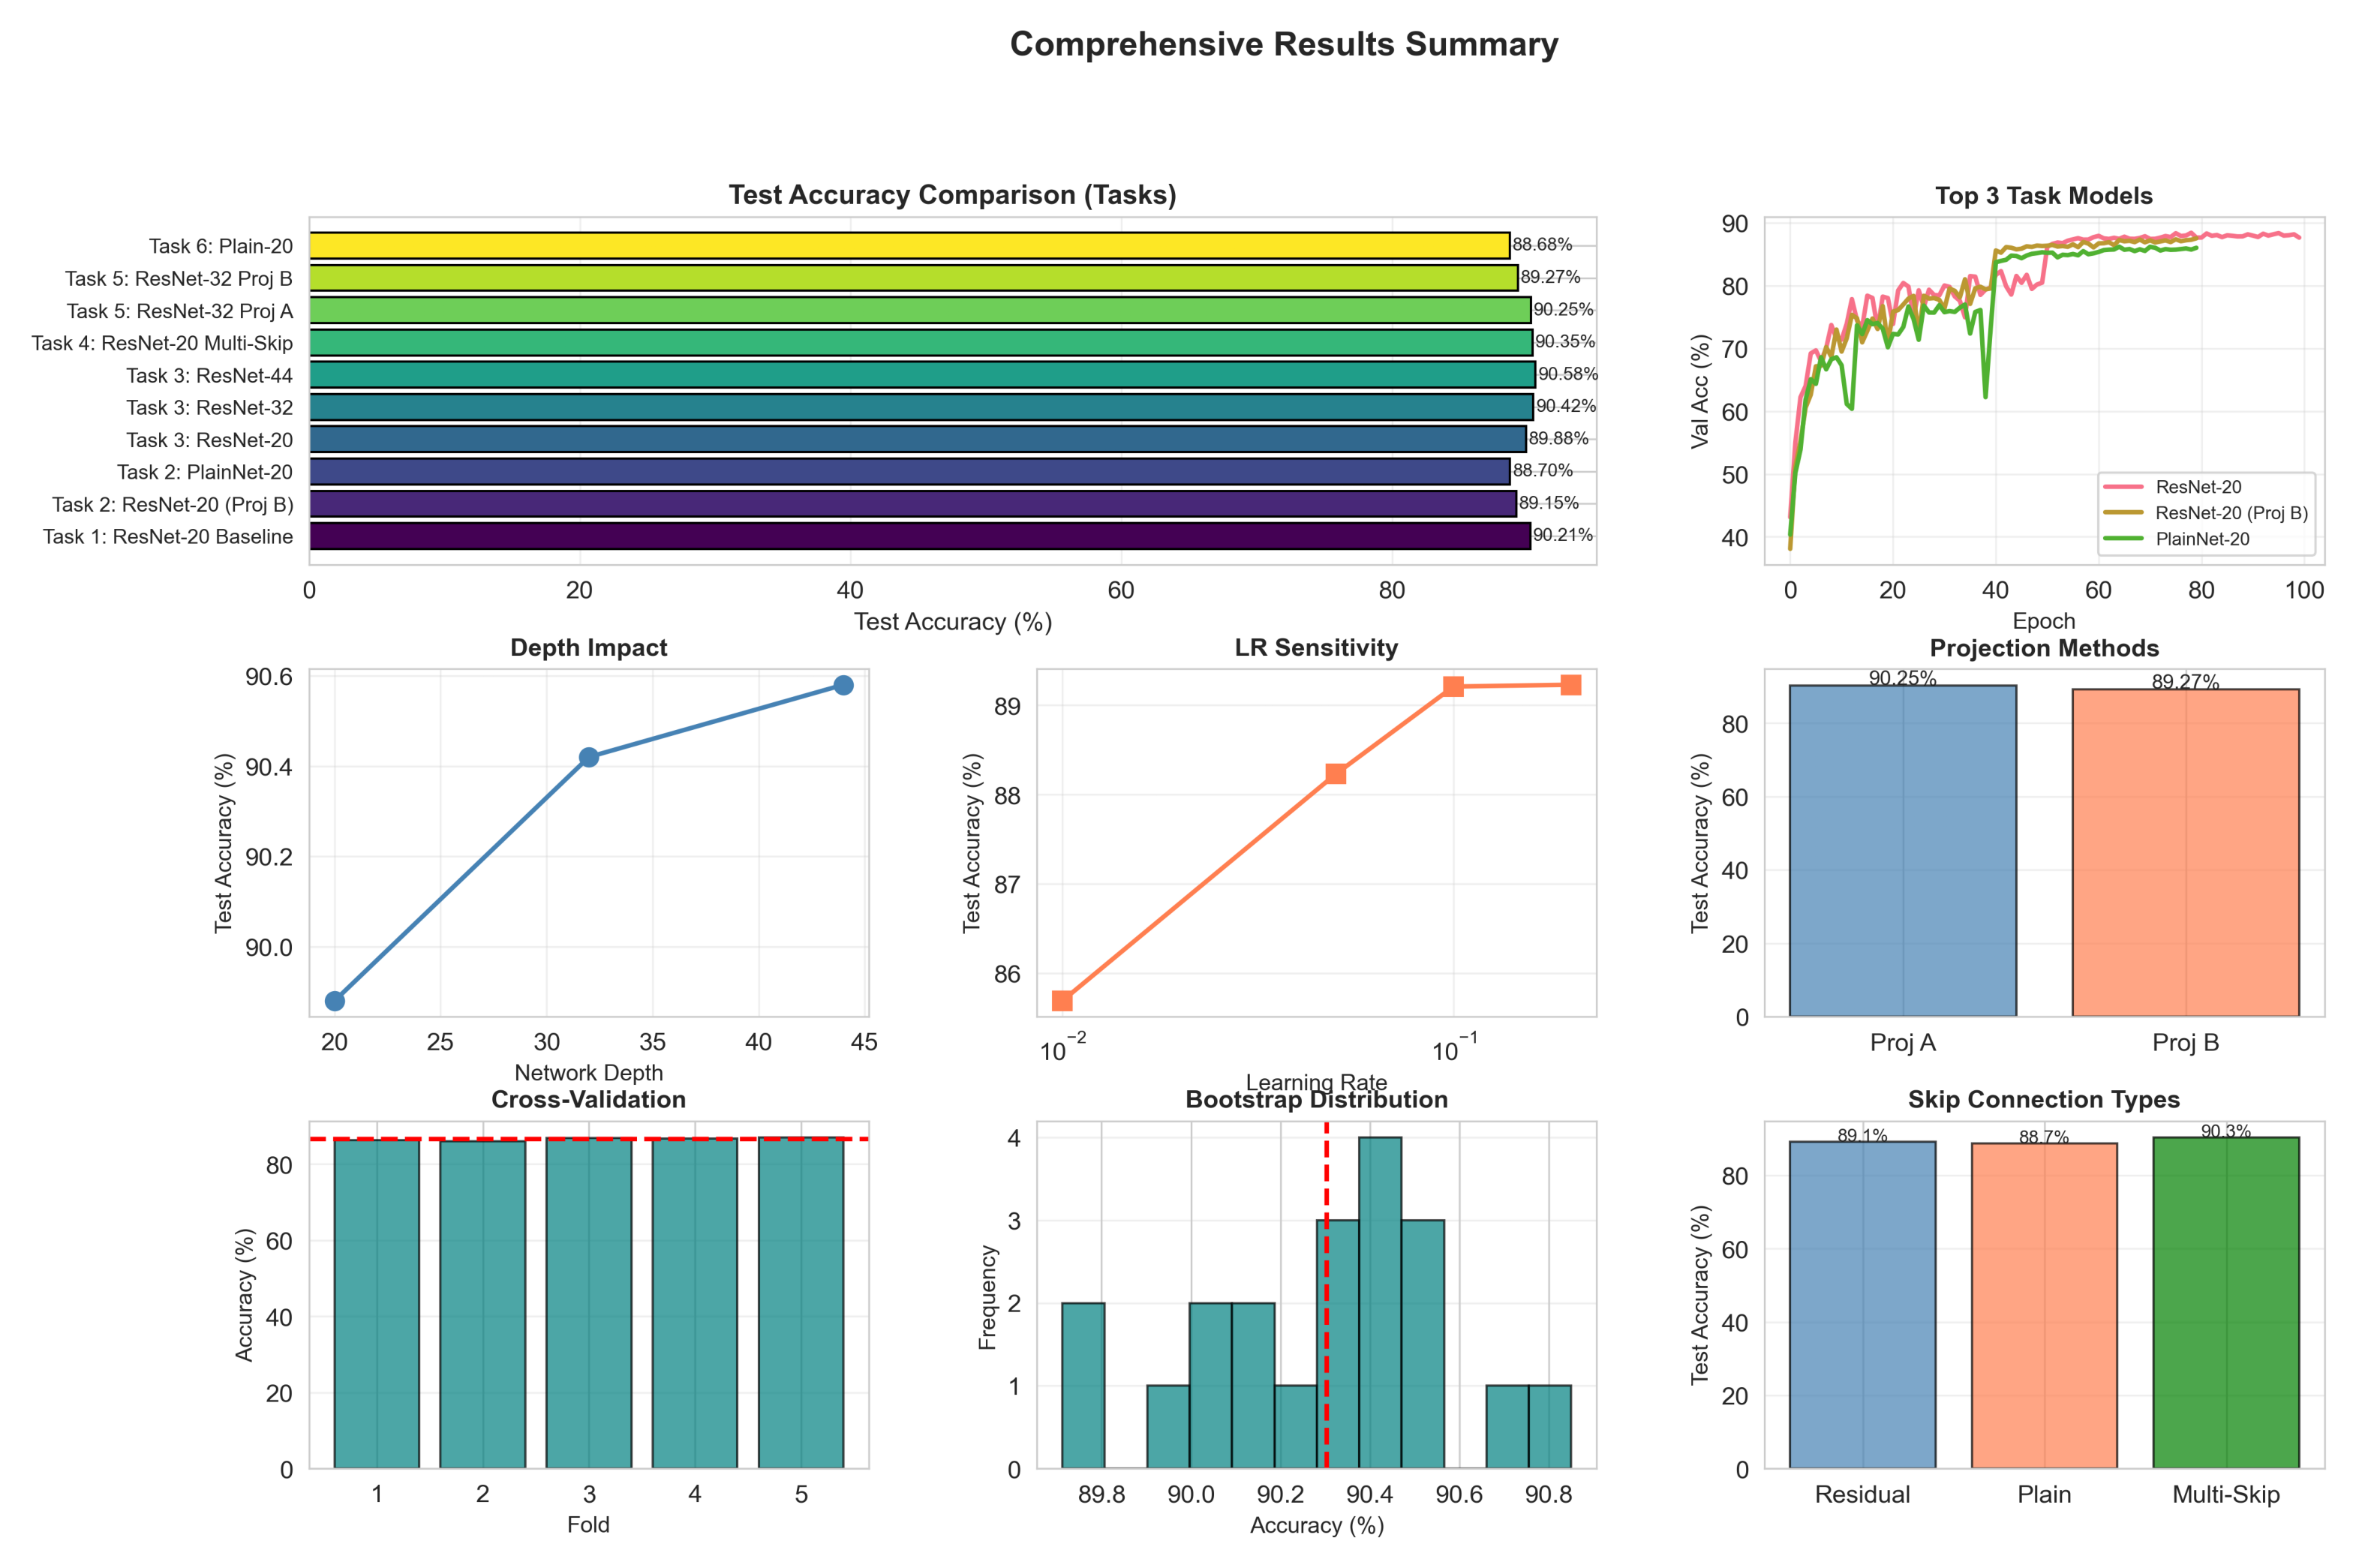


Checkpoints saved to: resnet_experiments\checkpoints

Best Test Accuracy: 90.58%
Average Test Accuracy: 89.75%

--- Task Statistical Comparison ---
             Model Best_Val_Acc  Best_Epoch Final_Train_Acc Final_Val_Acc Train_Val_Gap
         ResNet-20       88.42%          78          93.83%        87.65%         6.18%
ResNet-20 (Proj B)       87.54%          79          91.99%        87.54%         4.45%
       PlainNet-20       86.20%          64          90.28%        86.03%         4.25%
         ResNet-20       87.41%          73          92.45%        87.22%         5.23%
         ResNet-32       88.14%          74          94.19%        87.86%         6.33%
         ResNet-44       89.06%          66          94.91%        88.86%         6.05%


In [ ]:
# Comprehensive Visual Summary
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

ax1 = fig.add_subplot(gs[0, :2])
task_names = [r['Task'] for r in task_results[:10]]
task_accs = [float(r['Test_Acc'].rstrip('%')) for r in task_results[:10]]
colors_plot = plt.cm.viridis(np.linspace(0, 1, len(task_names)))
bars = ax1.barh(range(len(task_names)), task_accs, color=colors_plot, edgecolor='black')
ax1.set_yticks(range(len(task_names)))
ax1.set_yticklabels(task_names, fontsize=9)
ax1.set_xlabel('Test Accuracy (%)', fontsize=11)
ax1.set_title('Test Accuracy Comparison (Tasks)', fontsize=12, fontweight='bold')
ax1.grid(alpha=0.3, axis='x')
for i, (bar, acc) in enumerate(zip(bars, task_accs)):
    ax1.text(acc + 0.2, i, f'{acc:.2f}%', va='center', fontsize=8)

ax2 = fig.add_subplot(gs[0, 2])
for i, (hist, label) in enumerate(zip(task_histories[:3], task_labels[:3])):
    ax2.plot(hist['epoch'], [a*100 for a in hist['val_acc']], label=label, linewidth=2)
ax2.set_xlabel('Epoch', fontsize=10)
ax2.set_ylabel('Val Acc (%)', fontsize=10)
ax2.set_title('Top 3 Task Models', fontsize=11, fontweight='bold')
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)

ax3 = fig.add_subplot(gs[1, 0])
depth_accs_plot = [float(r['Test_Acc'].rstrip('%')) for r in task_results if 'Task 3:' in r['Task']][:3]
ax3.plot(depths, depth_accs_plot, 'o-', linewidth=2, markersize=8, color='steelblue')
ax3.set_xlabel('Network Depth', fontsize=10)
ax3.set_ylabel('Test Accuracy (%)', fontsize=10)
ax3.set_title('Depth Impact', fontsize=11, fontweight='bold')
ax3.grid(alpha=0.3)

ax4 = fig.add_subplot(gs[1, 1])
lr_accs_plot = [float(r['Test_Acc'].rstrip('%')) for r in exp_results if 'LR=' in r['Experiment']]
ax4.plot(lrs, lr_accs_plot, 's-', linewidth=2, markersize=8, color='coral')
ax4.set_xlabel('Learning Rate', fontsize=10)
ax4.set_ylabel('Test Accuracy (%)', fontsize=10)
ax4.set_title('LR Sensitivity', fontsize=11, fontweight='bold')
ax4.set_xscale('log')
ax4.grid(alpha=0.3)

ax5 = fig.add_subplot(gs[1, 2])
proj_data = ['Proj A', 'Proj B']
proj_accs = [test_acc_t5a*100, test_acc_t5b*100]
ax5.bar(proj_data, proj_accs, color=['steelblue', 'coral'], edgecolor='black', alpha=0.7)
ax5.set_ylabel('Test Accuracy (%)', fontsize=10)
ax5.set_title('Projection Methods', fontsize=11, fontweight='bold')
ax5.grid(alpha=0.3, axis='y')
for i, acc in enumerate(proj_accs):
    ax5.text(i, acc + 0.2, f'{acc:.2f}%', ha='center', fontsize=9)

ax6 = fig.add_subplot(gs[2, 0])
cv_accs = [r['best_acc']*100 for r in cv_results['folds']]
ax6.bar(range(1, 6), cv_accs, color='teal', edgecolor='black', alpha=0.7)
ax6.axhline(cv_results['mean']*100, color='red', linestyle='--', linewidth=2)
ax6.set_xlabel('Fold', fontsize=10)
ax6.set_ylabel('Accuracy (%)', fontsize=10)
ax6.set_title('Cross-Validation', fontsize=11, fontweight='bold')
ax6.grid(alpha=0.3, axis='y')

ax7 = fig.add_subplot(gs[2, 1])
boot_accs = [a*100 for a in boot_results['accs']]
ax7.hist(boot_accs, bins=12, color='teal', edgecolor='black', alpha=0.7)
ax7.axvline(boot_results['mean']*100, color='red', linestyle='--', linewidth=2)
ax7.set_xlabel('Accuracy (%)', fontsize=10)
ax7.set_ylabel('Frequency', fontsize=10)
ax7.set_title('Bootstrap Distribution', fontsize=11, fontweight='bold')
ax7.grid(alpha=0.3, axis='y')

ax8 = fig.add_subplot(gs[2, 2])
skip_data = ['Residual', 'Plain', 'Multi-Skip']
skip_accs = [test_acc_t2a*100, test_acc_t2b*100, test_acc_t4*100]
bars8 = ax8.bar(skip_data, skip_accs, color=['steelblue', 'coral', 'green'],
               edgecolor='black', alpha=0.7)
ax8.set_ylabel('Test Accuracy (%)', fontsize=10)
ax8.set_title('Skip Connection Types', fontsize=11, fontweight='bold')
ax8.grid(alpha=0.3, axis='y')
for bar, acc in zip(bars8, skip_accs):
    height = bar.get_height()
    ax8.text(bar.get_x() + bar.get_width()/2., height + 0.2,
            f'{acc:.1f}%', ha='center', fontsize=8)

plt.suptitle('Comprehensive Results Summary', fontsize=15, fontweight='bold', y=0.995)
plt.savefig(VISUALIZATION_DIR / 'comprehensive_summary.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

print(f"\nCheckpoints saved to: {CHECKPOINT_DIR}")

# Additional statistics and comparisons
all_test_accs = [float(r['Test_Acc'].rstrip('%')) for r in task_results[:10]]
print(f"\n{'='*60}")
print(f"Best Test Accuracy: {max(all_test_accs):.2f}%")
print(f"Average Test Accuracy: {np.mean(all_test_accs):.2f}%")
print(f"{'='*60}\n")

print("--- Task Statistical Comparison ---")
stats_data = []
for hist, label in zip(task_histories[:6], task_labels[:6]):
    stats_data.append({
        'Model': label,
        'Best_Val_Acc': f"{hist['best_acc']*100:.2f}%",
        'Best_Epoch': hist['best_epoch'],
        'Final_Train_Acc': f"{hist['train_acc'][-1]*100:.2f}%",
        'Final_Val_Acc': f"{hist['val_acc'][-1]*100:.2f}%",
        'Train_Val_Gap': f"{(hist['train_acc'][-1] - hist['val_acc'][-1])*100:.2f}%"
    })

stats_df = pd.DataFrame(stats_data)
print(stats_df.to_string(index=False))
stats_df.to_csv(RESULTS_DIR / 'task_statistical_comparison.csv', index=False)

In [ ]:
print(f"\n{'='*60}")
print("--- Task Performance Improvements ---")
baseline_acc = float(task_results[0]['Test_Acc'].rstrip('%'))
improvements = []

for result in task_results[:10]:
    test_acc = float(result['Test_Acc'].rstrip('%'))
    improvement = test_acc - baseline_acc
    improvements.append({
        'Task': result['Task'],
        'Test_Acc': result['Test_Acc'],
        'Improvement': f"{improvement:+.2f}%"
    })

improve_df = pd.DataFrame(improvements)
improve_df = improve_df.sort_values('Test_Acc', ascending=False)
print(improve_df.to_string(index=False))
improve_df.to_csv(RESULTS_DIR / 'task_improvements.csv', index=False)


--- Task Performance Improvements ---
                        Task Test_Acc Improvement
           Task 3: ResNet-44   90.58%      +0.37%
           Task 3: ResNet-32   90.42%      +0.21%
Task 4: ResNet-20 Multi-Skip   90.35%      +0.14%
    Task 5: ResNet-32 Proj A   90.25%      +0.04%
  Task 1: ResNet-20 Baseline   90.21%      +0.00%
           Task 3: ResNet-20   89.88%      -0.33%
    Task 5: ResNet-32 Proj B   89.27%      -0.94%
  Task 2: ResNet-20 (Proj B)   89.15%      -1.06%
         Task 2: PlainNet-20   88.70%      -1.51%
            Task 6: Plain-20   88.68%      -1.53%


In [ ]:
print(f"\n{'='*60}")
print("--- Architecture Analysis ---")
arch_comparison = [
    {'Architecture': 'ResNet-20', 'Parameters': '0.27M', 'Depth': 20, 'Skip_Type': 'Standard',
     'Best_Test_Acc': test_acc_t1*100},
    {'Architecture': 'ResNet-32', 'Parameters': '0.46M', 'Depth': 32, 'Skip_Type': 'Standard',
     'Best_Test_Acc': test_acc_t5b*100},
    {'Architecture': 'PlainNet-20', 'Parameters': '0.27M', 'Depth': 20, 'Skip_Type': 'None',
     'Best_Test_Acc': test_acc_t2b*100},
    {'Architecture': 'Multi-Skip-20', 'Parameters': '0.35M', 'Depth': 20, 'Skip_Type': 'Multi-Layer',
     'Best_Test_Acc': test_acc_t4*100},
    {'Architecture': 'Optimized-32', 'Parameters': '0.46M', 'Depth': 32, 'Skip_Type': 'Standard',
     'Best_Test_Acc': test_acc_e5*100}
]

arch_df = pd.DataFrame(arch_comparison)
arch_df = arch_df.sort_values('Best_Test_Acc', ascending=False)
print(arch_df.to_string(index=False))
arch_df.to_csv(RESULTS_DIR / 'architecture_comparison.csv', index=False)


--- Architecture Analysis ---
 Architecture Parameters  Depth   Skip_Type  Best_Test_Acc
 Optimized-32      0.46M     32    Standard          91.16
Multi-Skip-20      0.35M     20 Multi-Layer          90.35
    ResNet-20      0.27M     20    Standard          90.21
    ResNet-32      0.46M     32    Standard          89.27
  PlainNet-20      0.27M     20        None          88.70


In [ ]:
print(f"\n{'='*60}")
print("--- Training Efficiency ---")
efficiency_data = []
for hist, label in zip(task_histories[:6], task_labels[:6]):
    epochs_to_best = hist['best_epoch']
    final_epoch = len(hist['epoch']) - 1
    efficiency = (hist['best_acc'] / (epochs_to_best + 1)) * 100

    efficiency_data.append({
        'Model': label,
        'Epochs_to_Best': epochs_to_best,
        'Total_Epochs': final_epoch + 1,
        'Best_Accuracy': f"{hist['best_acc']*100:.2f}%",
        'Efficiency_Score': f"{efficiency:.2f}"
    })

eff_df = pd.DataFrame(efficiency_data)
eff_df = eff_df.sort_values('Efficiency_Score', ascending=False)
print(eff_df.to_string(index=False))
eff_df.to_csv(RESULTS_DIR / 'training_efficiency.csv', index=False)


--- Training Efficiency ---
             Model  Epochs_to_Best  Total_Epochs Best_Accuracy Efficiency_Score
       PlainNet-20              64            80        86.20%             1.33
         ResNet-44              66            80        89.06%             1.33
         ResNet-20              73            80        87.41%             1.18
         ResNet-32              74            80        88.14%             1.18
         ResNet-20              78           100        88.42%             1.12
ResNet-20 (Proj B)              79            80        87.54%             1.09


In [ ]:
print(f"\n{'='*60}")
print("--- Top 5 Models by Test Accuracy ---")
all_test_df = pd.DataFrame(task_results[:10])
all_test_df['Test_Acc_Float'] = all_test_df['Test_Acc'].str.rstrip('%').astype(float)
top5 = all_test_df.nlargest(5, 'Test_Acc_Float')[['Task', 'Val_Acc', 'Test_Acc']]
print(top5.to_string(index=False))


--- Top 5 Models by Test Accuracy ---
                        Task Val_Acc Test_Acc
           Task 3: ResNet-44  89.06%   90.58%
           Task 3: ResNet-32  88.14%   90.42%
Task 4: ResNet-20 Multi-Skip  88.90%   90.35%
    Task 5: ResNet-32 Proj A  88.63%   90.25%
  Task 1: ResNet-20 Baseline  88.42%   90.21%


###